In [1]:
import sys
sys.path.append('/home/aribra/jnps/thesis/public_repo/lattice_correction_net')
import numpy as np
from pylab import *

from synchrotron_simulator_gpu_Dataset_4D import SimulationRunner, SynchrotronSimulator
from automate_dataset_collection import SimulationDataset
import time

In [2]:
# ! pip install scikit-learn


In [3]:
# theta_kick = (k_nominal * delta * L_quad)  # Small angular kick

### Configurations

In [3]:
np.rad2deg(1.8)

103.13240312354819

In [4]:
np.deg2rad(30)

0.5235987755982988

In [5]:
# Define base simulation configurations with embedded quadrupole errors


base_configurations = [
    {
        'config_name': 'Configuration 1',
        'design_radius': 20.0,    # meters
        'n_FODO': 8,
        'f': 15,                 # meters
        'L_quad': 0.4,             # meters
        # 'L_straight': 1,         # meters
        # 'total_dipole_bending_angle': (2 * np.pi),#(3 / 3) * np.pi,
        
        'quad_errors': None,

        # 'quad_errors': [
            # {
            #     'FODO_index': 0,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-5,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 1,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-6,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 2,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 3,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 4,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 5,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 6,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
            # {
            #     'FODO_index': 7,
            #     'quad_type': 'defocusing',
            #     'delta': 1e-7,
            #     'plane': 'vertical'  # 'horizontal' or 'vertical'
            # },
        # ],

      "quad_tilt_errors": None,
        
        # 'quad_tilt_errors': [
        #     {
        #         'FODO_index': 1,
        #         'quad_type': 'defocusing',
        #         'tilt_angle': 0.0005
        #     },
        #     {
        #         'FODO_index': 3,
        #         'quad_type': 'defocusing',
        #         'tilt_angle': 0.0005
        #     },
        #     {
        #         'FODO_index': 6,
        #         'quad_type': 'defocusing',
        #         'tilt_angle': 0.0005
        #     },   
        # ],

        'dipole_tilt_errors': None,
        # 'dipole_tilt_errors': [
        #     {
        #         'FODO_index': 0,
        #         'dipole_index': 0,
        #         'tilt_angle': 0.005
        #     },
        #     {
        #         'FODO_index': 1,
        #         'dipole_index': 1,
        #         'tilt_angle': 0.005
        #     },
        #     {
        #         'FODO_index': 7,
        #         'dipole_index': 1,
        #         'tilt_angle': 0.005
        #     }
        # ],

    },
]

common_parameters = {
    'p': 5.344286e-19,                # Momentum in kg m/s (p_GeV_c=0.7)
    'G': 1.0,                         # Tesla/meter
    'q': 1.602e-19,                   # Proton charge in Coulombs
    'n_turns': 100,                   # Number of revolutions to simulate
    'num_particles': 1,             # Number of particles to simulate
    'window_size': 10,                # Average window size for moving averages
    'use_thin_lens': True,
    # Uniform - Initial conditions ranges as tuples
    'x0_mean_std': (0.0, 0.05),      # meters
    'xp0_mean_std': (0.0, 0.00),  # radians
    'y0_mean_std': (0.0, 0.05),      # meters
    'yp0_mean_std': (0.0, 0.00),  # radians
    'particles_sampling_method': 'from_twiss_params', # from_twiss_params | circle_with_radius | normal
    'correct_injection_offset': False,
    'sampling_circle_radius': 0.01, #meters,
    # Acceptable ranges config params
    'mag_field_range': [0.1, 2.0],           # Tesla
    'dipole_length_range': [0.2, 14.0],       # meters
    'horizontal_tune_range': [0.1, 0.8],     # Tune
    'vertical_tune_range': [0.1, 0.8],        # Tune
    'total_dipole_bending_angle_range': (1.5 * np.pi, 2 * np.pi),
    # Use cuda GPU kernels to accelerate simulation
    'use_gpu': False,
    # Log
    'verbose': True,
    # BPM readings log criterion
    # record_full_revolution. By default records for cell_idx=0
    # 'record_full_revolution': False,
    # enable storing BPM readings for all BPMs after each full revolution relative to each BPM
    # requires to set record_full_revolution to `True`
    # 'record_full_revolution_per_bpm': False,
    
    
    # Parameters for generate_data
    'target_data': 'quad_misalign_deltas',  # ['quad_misalign_deltas', 'quad_tilt_angles', 'dipole_tilt_angles']
    'reject_multiple_error_types': False,
    'start_rev': -1,
    'end_rev': -1, # should be same as <= n_turns
    'apply_avg': False,
    'fodo_cell_indices': [0, 1, 2, 3, 4, 5, 6, 7],  # Indices of BPMs to consider
    'planes': ['x', 'y'],
    'random_criterion': 'normal', # uniform | normal
    # if 'random_criterion' is 'uniform'
        # then >> _range is (low, high)
    # if 'random_criterion' is 'normal'
        # then >> _range is (mean, std)
    'delta_range': (0, 5e-5),
    'quad_tilt_angle_range': (0, 0.010), # 10 mrad (1e-3 = 1 mrad)
    'dipole_tilt_angle_range': (0, 0.05), # 50 mrad
    'com_delta_range': (-5e-05, 5e-05),
}



In [6]:
base_configurations

[{'config_name': 'Configuration 1',
  'design_radius': 20.0,
  'n_FODO': 8,
  'f': 15,
  'L_quad': 0.4,
  'quad_errors': None,
  'quad_tilt_errors': None,
  'dipole_tilt_errors': None}]

In [7]:
sampling_func = None
if common_parameters['random_criterion'] == 'uniform':
    sampling_func = np.random.uniform
elif common_parameters['random_criterion'] == 'normal':
    sampling_func = np.random.normal


# Target prediction (Misalignment)
quadrupole_errors_target_values = {}

base_config = base_configurations[0]

if base_config['quad_errors']:
    fodo_indices_with_error = [err['FODO_index'] for err in base_config['quad_errors']]
else:
    fodo_indices_with_error = []

if base_config['quad_tilt_errors']:
    fodo_indices_with_quad_tilt_error = [err['FODO_index'] for err in base_config['quad_tilt_errors']]
else:
    fodo_indices_with_quad_tilt_error = []

mean_or_min_delta, std_or_max_delta = common_parameters['delta_range']
mean_or_min_quad_tilt_error, std_or_max_quad_tilt_error = common_parameters['quad_tilt_angle_range']

# # Apply quad misalignment errors
# if base_config['quad_errors']:
#     for qe_ix, qe in enumerate(base_config['quad_errors']):
#         if base_config['quad_errors'][qe_ix]['FODO_index'] in fodo_indices_with_error:
#             quadrupole_error_delta = sampling_func(mean_or_min_delta, std_or_max_delta)
#             quadrupole_errors_target_values[qe_ix] = quadrupole_error_delta
#             base_config['quad_errors'][qe_ix]['delta'] = quadrupole_error_delta
#             print("_run_evaluation()/ ", qe_ix, qe)
#         else:
#             base_config['quad_errors'][qe_ix]['delta'] = 0.0

# Apply quad_tilt_errors
if base_config['quad_tilt_errors']:
    for qe_ix, qe in enumerate(base_config['quad_tilt_errors']):
        if base_config['quad_tilt_errors'][qe_ix]['FODO_index'] in fodo_indices_with_quad_tilt_error:
            quadrupole_tilt_error_delta = sampling_func(mean_or_min_quad_tilt_error, std_or_max_quad_tilt_error)
            print("quadrupole_tilt_error_delta: ", quadrupole_tilt_error_delta)
            
            # TODO(aribra): # Target prediction (Quadrupole Tilt)
            # quadrupole_errors_target_values[qe_ix] = quadrupole_tilt_error_delta
            
            base_config['quad_tilt_errors'][qe_ix]['tilt_angle'] = quadrupole_tilt_error_delta
            print("_run_evaluation()/ ", qe_ix, qe)
        else:
            base_config['quad_tilt_errors'][qe_ix]['tilt_angle'] = 0.0

base_configurations = [base_config]

In [8]:
fodo_indices_with_quad_tilt_error

[]

In [9]:
360 + 90

450

In [10]:
rad2deg(np.pi / 2 * 5)

450.0

In [11]:
# Call the classmethod to find feasible lattices
feasible_lattices = SynchrotronSimulator.find_feasible_lattices(
    base_configurations=base_configurations,
    common_parameters=common_parameters,
    
)

# Check the results
def print_all_feasible_configs(feasible_lattices):
    if feasible_lattices:
        print(f"Found {len(feasible_lattices)} feasible lattice configurations.")
        for idx, config in enumerate(feasible_lattices):
            print(f"\nConfiguration {idx + 1}:")
            for key, value in config.items():
                if isinstance(value, float):
                    print(f"{key}: {value:.4f}")
                else:
                    print(f"{key}: {value}")
    else:
        print("No feasible lattice configurations found.")

check_config =  {'design_radius': 20.0, 'L_quad': 0.4, 'n_FODO': 8, 'L_straight': 3.9269908169872423, 'L_dipole': 5.890486225480862, 'n_Dipoles': 16, 'L_drift': 0.7817477042468106, 'G': 1.0, 'p': 5.344286e-19, 'q': 1.602e-19, 'total_dipole_bending_angle': 4.71238898038469}
build_lattice() completed. Total elements per rev = 64
one turn matrix:
 [[-1.24580699  4.44129232  0.          0.        ]
 [-0.02508091 -0.71327933  0.          0.        ]
 [ 0.          0.          0.98635379  9.32385644]
 [ 0.          0.         -0.12117472 -0.13161168]]
compute_tune_4x4()/ evals =  [-0.97954316+0.2012342j  -0.97954316-0.2012342j   0.42737106+0.90407631j
  0.42737106-0.90407631j]
compute_tune_4x4()/ angles =  [0.17971989927789359, 0.4677523855413337, 0.5322476144586663, 0.8202801007221064]
			=========== angles = [0.17971989927789359, 0.4677523855413337, 0.5322476144586663, 0.8202801007221064]
compute_tune_4x4()/  0.17971989927789359 0.4677523855413337
compute_tunes()/ 0.4677523855413337 0.1797

In [12]:
len(feasible_lattices)

8

In [13]:
np.rad2deg(4.71238898038469)

270.0

In [14]:
lattice_design = feasible_lattices[0]
lattice_design, 1 / lattice_design['f']

({'design_radius': 20.0,
  'L_quad': 0.4,
  'n_FODO': 8,
  'L_straight': 3.9269908169872423,
  'L_dipole': 5.890486225480862,
  'n_Dipoles': 16,
  'L_drift': 0.7817477042468106,
  'Qx': 0.4677523855413337,
  'Qy': 0.17971989927789359,
  'B': 0.16680043695380775,
  'B_rho': 3.336008739076155,
  'f': 3.336008739076155,
  'G': 1.0,
  'p': 5.344286e-19,
  'q': 1.602e-19,
  'total_dipole_bending_angle': 4.71238898038469},
 0.29975940658864436)

In [15]:
lattice_design = feasible_lattices[0]
lattice_design, 1 / lattice_design['f']

({'design_radius': 20.0,
  'L_quad': 0.4,
  'n_FODO': 8,
  'L_straight': 3.9269908169872423,
  'L_dipole': 5.890486225480862,
  'n_Dipoles': 16,
  'L_drift': 0.7817477042468106,
  'Qx': 0.4677523855413337,
  'Qy': 0.17971989927789359,
  'B': 0.16680043695380775,
  'B_rho': 3.336008739076155,
  'f': 3.336008739076155,
  'G': 1.0,
  'p': 5.344286e-19,
  'q': 1.602e-19,
  'total_dipole_bending_angle': 4.71238898038469},
 0.29975940658864436)

In [16]:
for i, fl in enumerate(feasible_lattices):
    print(i, fl['n_FODO'], fl['Qx'], fl['Qy'], 1 / lattice_design['f'], np.rad2deg(fl['total_dipole_bending_angle']))

0 8 0.4677523855413337 0.17971989927789359 0.29975940658864436 270.0
1 8 0.47783104587088016 0.1797198992778936 0.29975940658864436 280.0
2 8 0.48789906967164287 0.1797198992778935 0.29975940658864436 290.0
3 8 0.4979597668876688 0.17971989927789353 0.29975940658864436 300.0
4 8 0.4919835305017182 0.17971989927789359 0.29975940658864436 310.0
5 8 0.4819274665208009 0.1797198992778936 0.29975940658864436 320.0
6 8 0.4718686592685798 0.17971989927789353 0.29975940658864436 330.0
7 8 0.4618036990153032 0.1797198992778936 0.29975940658864436 340.0


In [17]:
def override_base_config(base_config, lattice_design):
    for param in lattice_design.keys():
        base_config[param] = lattice_design[param]
    return base_config

In [18]:
overridden_base_config = override_base_config(base_configurations[0], lattice_design)
base_configurations = [overridden_base_config]

In [19]:
base_configurations[0]

{'config_name': 'Configuration 1',
 'design_radius': 20.0,
 'n_FODO': 8,
 'f': 3.336008739076155,
 'L_quad': 0.4,
 'quad_errors': None,
 'quad_tilt_errors': None,
 'dipole_tilt_errors': None,
 'L_straight': 3.9269908169872423,
 'L_dipole': 5.890486225480862,
 'n_Dipoles': 16,
 'L_drift': 0.7817477042468106,
 'Qx': 0.4677523855413337,
 'Qy': 0.17971989927789359,
 'B': 0.16680043695380775,
 'B_rho': 3.336008739076155,
 'G': 1.0,
 'p': 5.344286e-19,
 'q': 1.602e-19,
 'total_dipole_bending_angle': 4.71238898038469}

In [20]:

# base_configurations

### Run simulation


Running Configuration 1:
  n_FODO=8, design_radius=20.0m, f=3.336008739076155m, L_quad=0.4m, L_straight=3.9269908169872423m
build_lattice() completed. Total elements per rev = 64
one turn matrix:
 [[-1.24580699  4.44129232  0.          0.        ]
 [-0.02508091 -0.71327933  0.          0.        ]
 [ 0.          0.          0.98635379  9.32385644]
 [ 0.          0.         -0.12117472 -0.13161168]]
compute_tune_4x4()/ evals =  [-0.97954316+0.2012342j  -0.97954316-0.2012342j   0.42737106+0.90407631j
  0.42737106-0.90407631j]
compute_tune_4x4()/ angles =  [0.17971989927789359, 0.4677523855413337, 0.5322476144586663, 0.8202801007221064]
			=========== angles = [0.17971989927789359, 0.4677523855413337, 0.5322476144586663, 0.8202801007221064]
compute_tune_4x4()/  0.17971989927789359 0.4677523855413337
compute_tunes()/ 0.4677523855413337 0.17971989927789359
[Info] Using `cpu` backend for simulation.

Synchrotron Configuration:
Design Radius: 20.0 meters
Lattice Circumference: 125.6637061435

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2437: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  legend = plt.legend(facecolor='gray', edgecolor='white', framealpha=0.7)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


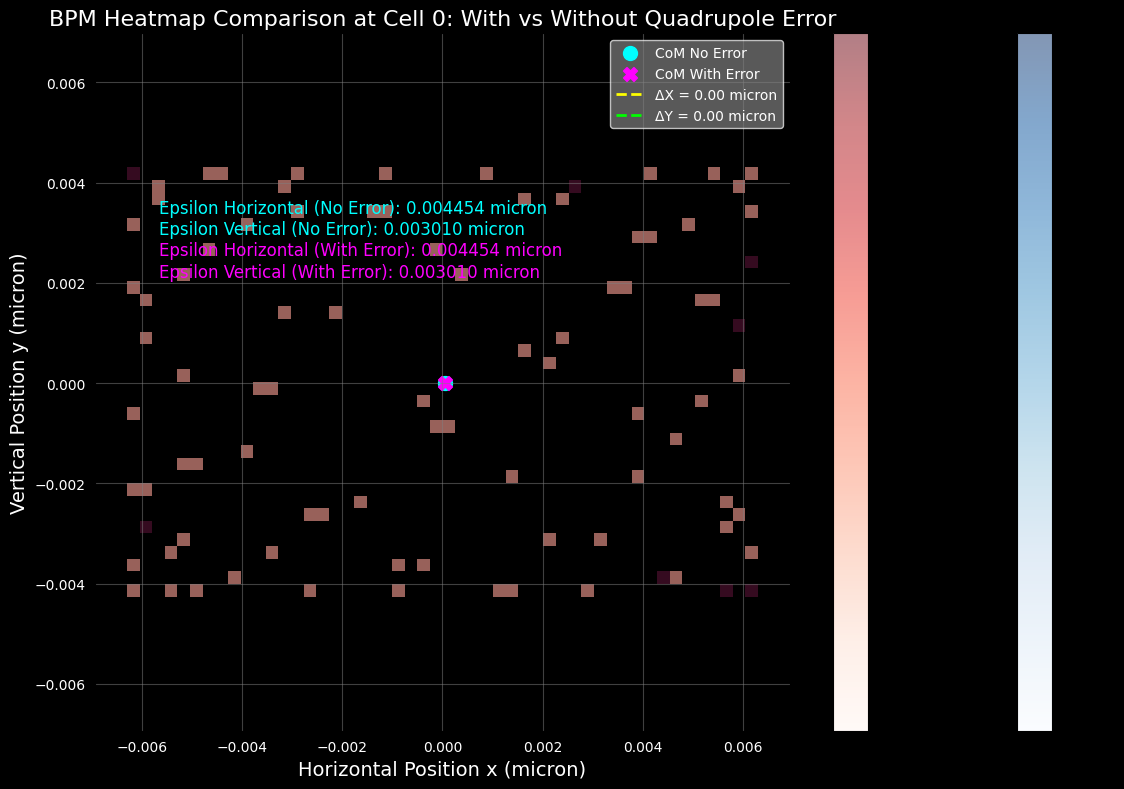

plot_comparison() - BPM 0/
	 CoM No error: X = 2.721297332593951e-05, Y = 4.244370262930058e-06
	 CoM With Error: X = 2.721297332593951e-05, Y = 4.244370262930058e-06
----
	 ΔX = 0.0000000 m, 0.00 micron
	 ΔY = 0.0000000 m, 0.00 micron
	 beam epsilon X = 0.0044544 m, 4454.44 micron
	 beam epsilon Y = 0.0030101 m, 3010.07 micron
----
An unexpected error occurred in configuration 'Configuration 1': '>' not supported between instances of 'int' and 'NoneType'
Skipping this configuration.

Traceback (most recent call last):
  File "/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py", line 3852, in run_configurations
    simulator_no_error.plot_comparison(simulator_with_error, cell_idx=cell_idx, viz_start_idx=None,
  File "/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py", line 3315, in plot_comparison
    bpm_data = process_bpm(cell)
  File "/home/aribra/jnps/thesis/public_repo/lattice_correc

In [21]:
runner = SimulationRunner(
    base_configurations=base_configurations,
    common_parameters=common_parameters
)

# Run all configurations
# initial_states = [[0.05, 0.001, 0.05, 0.001]] * common_parameters['num_particles']

initial_states = None

# initial_states =  [[-0.00381691,  0.00024301,  0.003036,    0.00021282]]


# initial_states = [[ 0.00000000e+00, -1.75842232e-05, -0.00000000e+00, -0.00000000e+00]]

runner.run_configurations(initial_states=initial_states)

# Example of accessing a specific simulator instance for further analysis
# For instance, accessing 'Configuration 1 - With Error'
config_key = 'Configuration 1 - With Error'
if config_key in runner.simulators_with_error:
    simulator = runner.simulators_with_error[config_key]
    # Perform additional analysis or plotting as needed
    # Example: simulator.plot_additional_metrics()
else:
    print(f"{config_key} not found in simulators_with_error.")



In [23]:
sim_no_error = runner.simulators_no_error['Configuration 1 - No Error']
sim_with_error = runner.simulators_with_error['Configuration 1 - With Error']

In [24]:
sim_with_error.bpm_readings['x'].shape

(1, 100, 8)

In [25]:
sim_with_error.bpm_readings.keys()

dict_keys(['x', 'y', 'xp', 'yp', 's'])

In [26]:
common_parameters['start_rev'] = 499

In [ ]:
merged_config = {**common_parameters, **base_configurations[0]}


simulation_dataset = SimulationDataset(
    merged_config=merged_config,
    bpm_readings_no_error=sim_no_error.bpm_readings,
    bpm_readings_with_error=sim_with_error.bpm_readings,
    bpm_positions=sim_no_error.bpm_positions,
    quadrupole_errors=sim_with_error.quad_errors,
    quadrupole_tilt_errors=sim_with_error.quadrupole_tilt_errors,
    dipole_tilt_errors=sim_with_error.dipole_tilt_errors,
    lattice_reference=sim_no_error.get_lattice_reference(),
    apply_avg=common_parameters.get('apply_avg', False),
    
)

start_rev = common_parameters.get('start_rev', 0)
end_rev = common_parameters.get('end_rev', sim_no_error.n_turns)
fodo_cell_indices = common_parameters.get('fodo_cell_indices', list(range(sim_no_error.n_FODO)))
planes = common_parameters.get('planes', ['x, y'])


print(f"[Evaluation - Generate data params:]\n"
    f"\t start_rev={start_rev}\n"
    f"\t end_rev={end_rev}\n"
    f"\t fodo_cell_indices={fodo_cell_indices}\n"
    f"\t planes={planes}")

(input_tensor, target_tensor,
 error_values_quad_misalign,
 error_values_quad_tilt,
 error_values_dipole_tilt) = simulation_dataset.process_simulated_data(
    start_rev, end_rev, fodo_cell_indices, planes
)



Lattice Reference:
Design Radius: 20.0 meters
Lattice Circumference: 125.66370614359172 meters
Number of FODO Cells: 8
Total Length per FODO Cell: 15.707963267948966
Total Length of All FODO Cells: 125.66371 meters
Number of Dipoles: 16
Quadrupole Focal Length (f): 3.336008739076155 meters
Focusing Index 0.29975940658864436
Quadrupole Length (L_quad): 0.4 meters
Straight Section Length (L_straight): 2.3634954084936215 meters
Drift Section Length: 0.7817477042468106 meters
Dipole Length per Dipole: 5.89049 meters
Dipole Bending Angle per Dipole: 16.87500 degrees
Number of Turns: 100
Number of Particles: 1
Magnetic Field (B): 0.16680 Tesla
Magnetic Field Rigidity (B_rho): 3.33601 Tesla/meters
Horizontal Tune (Qx): 0.467752
Vertical Tune (Qy): 0.179720
Number of turns for Full Oscillation (X): 2
Number of turns for Full Oscillation (Y): 6

Error Configuration:
  Quadrupole Error: None
  Quadrupole Tilt Error: None
  Dipole Tilt Error: None
[Evaluation - Generate data params:]
	 start_rev

ValueError: This exception indicates that you selected a `target_data` type, but did not configure any errors in the configuration. Check `target_data` value and if there were any errors configured for that target error type.

In [36]:
input_tensor.shape

torch.Size([1, 101, 8, 2])

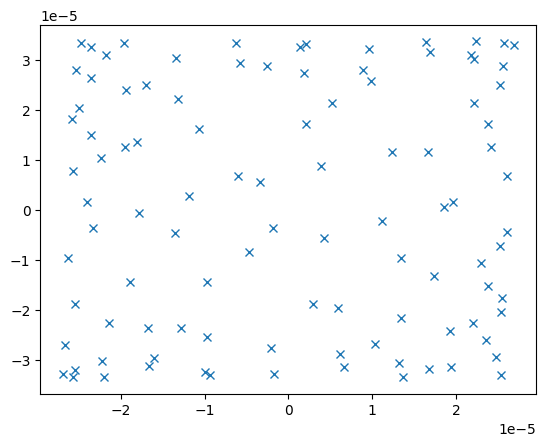

In [40]:
plot(
    input_tensor[0, :, 3, 0],
    input_tensor[0, :, 3, 1],
    'x'
)

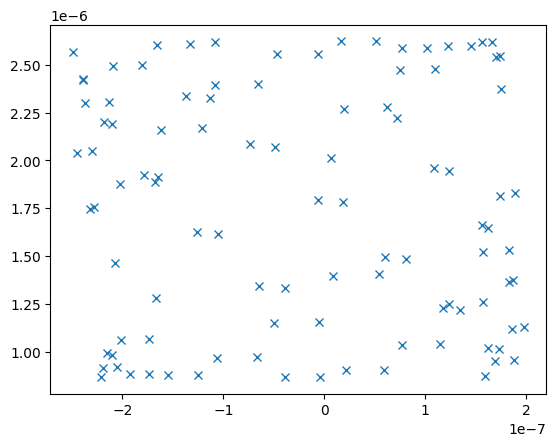

In [66]:
plot(
    input_tensor[0, :, 0, 0],
    input_tensor[0, :, 0, 1],
    'x'
)

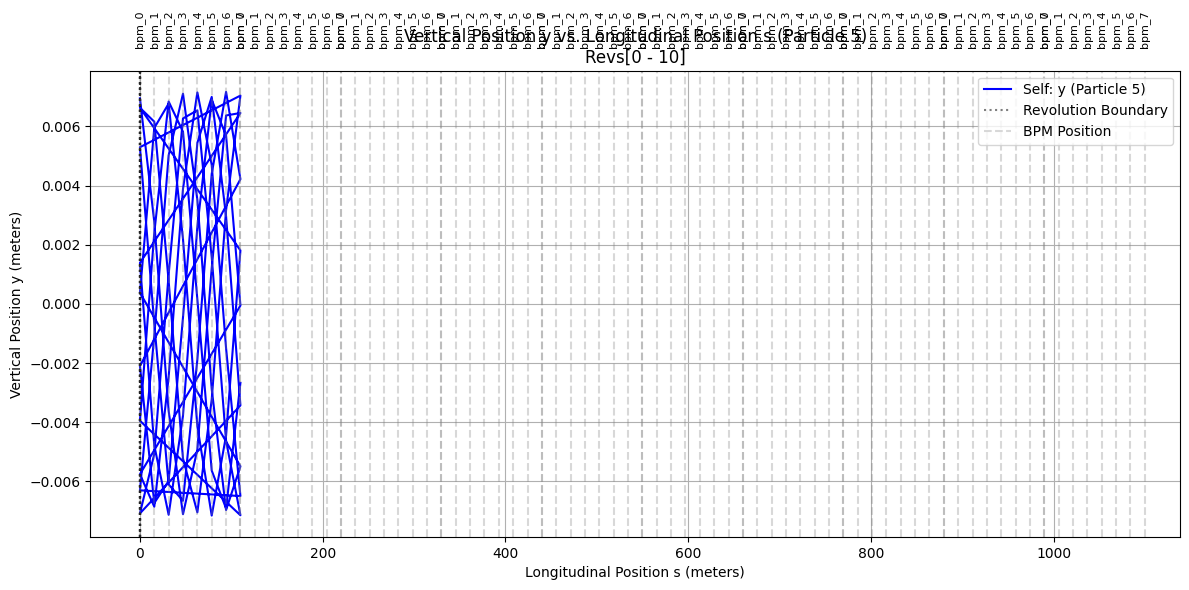

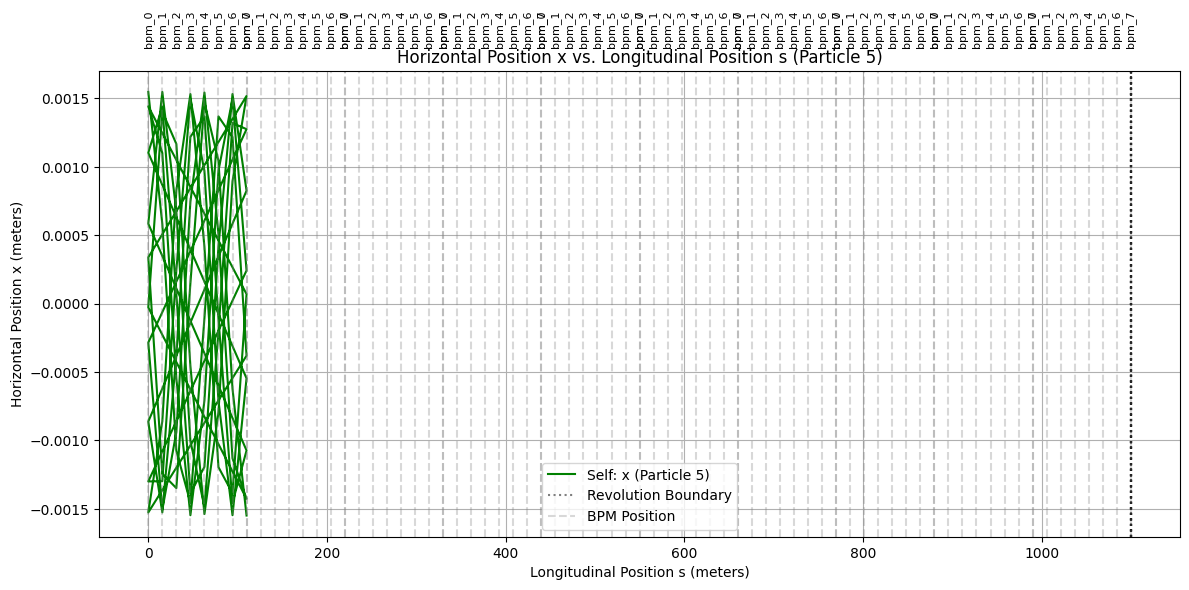

In [27]:
# sim_no_error.plot_transverse_vs_longitudinal(particle_idx=5, other_simulator=sim_with_error, start_rev=0, end_rev=10)
sim_no_error.plot_transverse_vs_longitudinal(particle_idx=5, other_simulator=None, start_rev=0, end_rev=10)

### Save `bpm_readings` Data

In [29]:
def save_bpm_data(bpm_readings, tag='bpm_readings'):
    # Extract s-positions for self simulator
    s_bpm_self = []
    elements_per_cell = {}
    for elem in sim_no_error.lattice_elements_positions:
        cell_idx = elem['cell_index']
        if cell_idx not in elements_per_cell:
            elements_per_cell[cell_idx] = []
        elements_per_cell[cell_idx].append(elem)
    
    for cell_idx in sorted(elements_per_cell.keys()):
        last_elem = elements_per_cell[cell_idx][-1]
        s_bpm_self.append(last_elem['end_s'])
    s_bpm_self = np.array(s_bpm_self)
    
    # Adjust to start at s=0
    s_offset_self = s_bpm_self[0]
    s_bpm_self_adjusted = s_bpm_self - s_offset_self
    s_values_self = np.tile(s_bpm_self_adjusted, sim_no_error.n_turns)
    
    bpm_readings['s'] = s_values_self
    bpm_readings['elements_per_cell'] = elements_per_cell
    
    
    np.save(tag, bpm_readings)

save_bpm_data(sim_no_error.bpm_readings, tag="NO-ERROR_100-particles_5k-turns_50-fodo")
save_bpm_data(sim_with_error.bpm_readings, tag="WITH-ERROR_100-particles_5k-turns_50-fodo")

In [469]:
x = np.load("bpm_readings_10k_revs_no_error.npy", allow_pickle=True)
data_dict = x.item()
data_dict.keys()

dict_keys(['x', 'y', 'xp', 'yp', 's', 'elements_per_cell'])

In [470]:
data_dict['y'][0][0],

(array([ 7.38491662e-04,  1.00299497e-03,  3.48698957e-05, -9.76108457e-04,
        -7.87500547e-04,  3.68904365e-04,  1.07194510e-03,  4.57621347e-04,
        -7.19095116e-04, -1.01208128e-03, -6.12724585e-05,  9.64837006e-04,
         8.05212232e-04, -3.43976279e-04, -1.07043593e-03, -4.81385782e-04,
         6.99262322e-04,  1.02055359e-03,  8.76378497e-05, -9.52980225e-04,
        -8.22435425e-04,  3.18839516e-04,  1.06827736e-03,  5.04858178e-04,
        -6.79005311e-04, -1.02840677e-03, -1.13950074e-04,  9.40545307e-04,
         8.39159677e-04, -2.93509325e-04, -1.06547071e-03, -5.28024296e-04,
         6.58336374e-04,  1.03563606e-03,  1.40193170e-04, -9.27539795e-04,
        -8.55374843e-04,  2.68001072e-04,  1.06201768e-03,  5.50870082e-04,
        -6.37268048e-04, -1.04223706e-03, -1.66351215e-04,  9.13971580e-04,
         8.71071085e-04, -2.42330234e-04, -1.05792036e-03, -5.73381675e-04,
         6.15813117e-04,  1.04820578e-03,  1.92408341e-04, -8.99848892e-04,
        -8.8

In [468]:
data_dict['y'][0][0]

array([ 7.38491662e-04,  1.00299497e-03,  3.48698957e-05, -9.76108457e-04,
       -7.87500547e-04,  3.68904365e-04,  1.07194510e-03,  4.57621347e-04,
       -7.19095116e-04, -1.01208128e-03,  4.95854560e-05,  1.16117217e-03,
        8.45738992e-04, -5.09063191e-04, -1.23825333e-03, -4.45694859e-04,
        8.94599289e-04,  1.13547768e-03, -1.90866353e-05, -1.15019447e-03,
       -8.67773435e-04,  4.81095788e-04,  1.23872344e-03,  4.74024744e-04,
       -8.73225580e-04, -1.14732732e-03, -1.14237644e-05,  1.13851900e-03,
        8.89281434e-04, -4.52836522e-04, -1.23844207e-03, -5.02067057e-04,
        8.51322117e-04,  1.15848092e-03,  4.19272338e-05, -1.12615283e-03,
       -9.10249938e-04,  4.24302537e-04,  1.23740938e-03,  5.29804784e-04,
       -8.28902190e-04, -1.16893171e-03, -7.24052675e-05,  1.11310346e-03,
        9.30666228e-04, -3.95511144e-04, -1.23562600e-03, -5.57221098e-04,
        8.05979399e-04,  1.17867335e-03,  1.02839376e-04, -1.09937882e-03,
       -9.50517918e-04,  

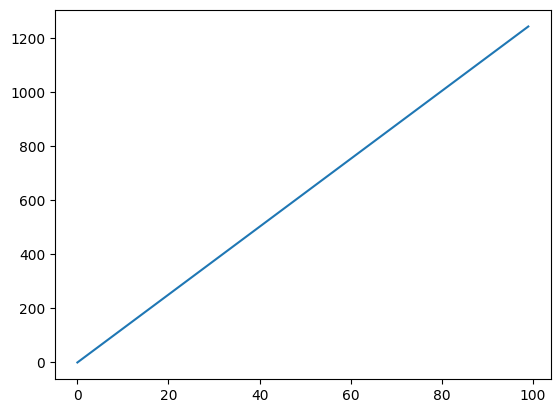

In [459]:
plot(s_values_self[:100])

In [45]:

def get_bpm_s_positions(simulator):
    s_positions = []
    elements_per_cell = {}
    for elem in simulator.lattice_elements_positions:
        cell_idx = elem['cell_index']
        if cell_idx not in elements_per_cell:
            elements_per_cell[cell_idx] = []
        elements_per_cell[cell_idx].append(elem)
    
    # Get the end_s of the last element in each FODO cell
    for cell_idx in sorted(elements_per_cell.keys()):
        last_elem = elements_per_cell[cell_idx][-1]
        s_positions.append(last_elem['end_s'])
    
    return np.array(s_positions)

# Example usage
s_bpm = get_bpm_s_positions(simulator)
circumference = sim_no_error.circumference
n_turns = sim_no_error.n_turns
n_FODO = sim_no_error.n_FODO

# Create s-values for all turns, resetting to 0 at each turn
s_values = []
for turn in range(n_turns):
    s_turn = s_bpm
    s_values.append(s_turn)
s_values = np.concatenate(s_values)

# For continuous plotting with resets, optionally use modulo
# s_values_modulo = s_values % circumference  # Uncomment for wrapped s-values

In [46]:
s_values

array([ 15.70796327,  31.41592654,  47.1238898 , ...,  94.24777961,
       109.95574288, 125.66370614])

In [67]:
np.insert(s_bpm, 0, [0])

array([  0.        ,  15.70796327,  31.41592654,  47.1238898 ,
        62.83185307,  78.53981634,  94.24777961, 109.95574288,
       125.66370614])

In [56]:
n_turns

10

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


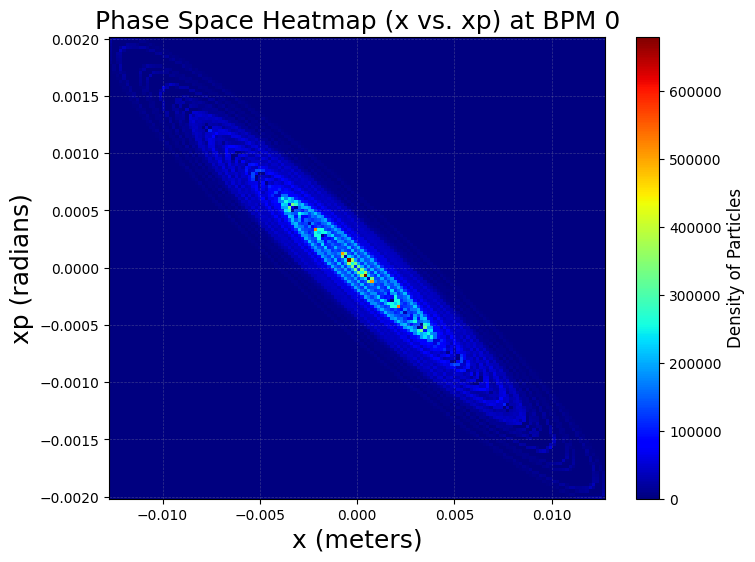

In [30]:
sim_no_error.plot_phase_space_diagram(first_axis='x', second_axis='xp', plot_all=False, start_idx=0, save_label='test_no_error', fontsize=18)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


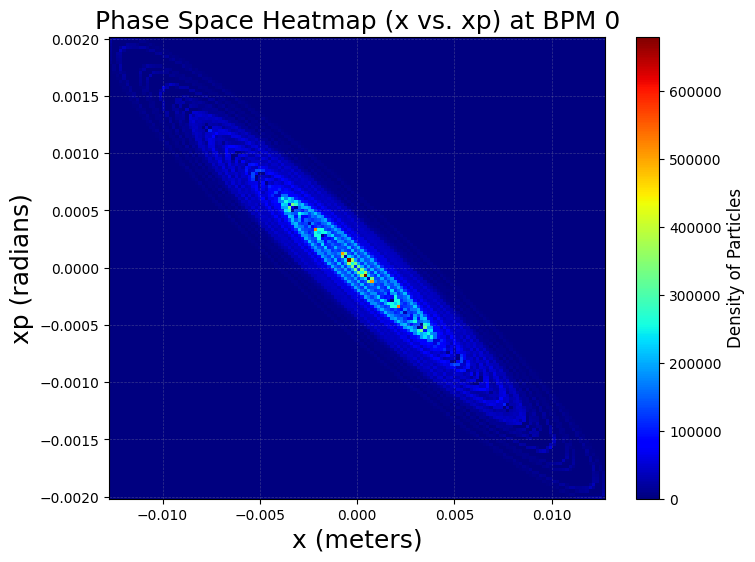

In [31]:
sim_with_error.plot_phase_space_diagram(first_axis='x', second_axis='xp', plot_all=False, start_idx=0 ,save_label='test_with_error', fontsize=18)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


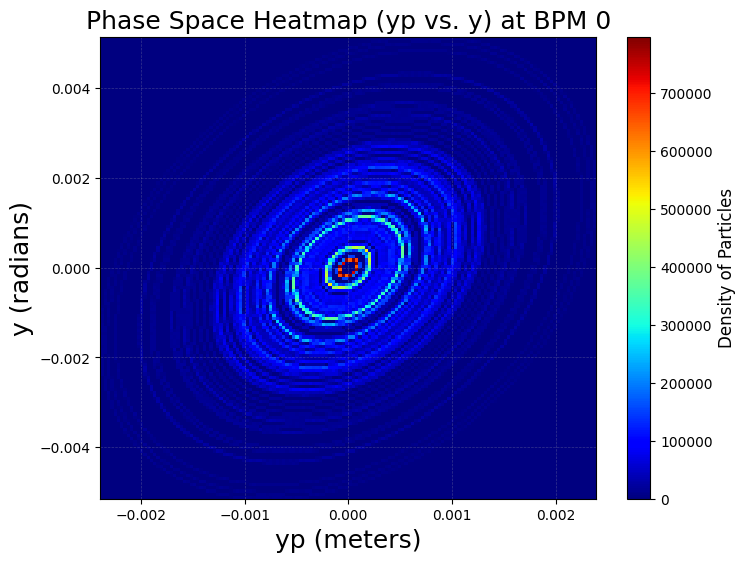

In [32]:
sim_no_error.plot_phase_space_diagram(first_axis='yp', second_axis='y', plot_all=False, start_idx=0, save_label='y_yp_test_no_error', fontsize=18)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


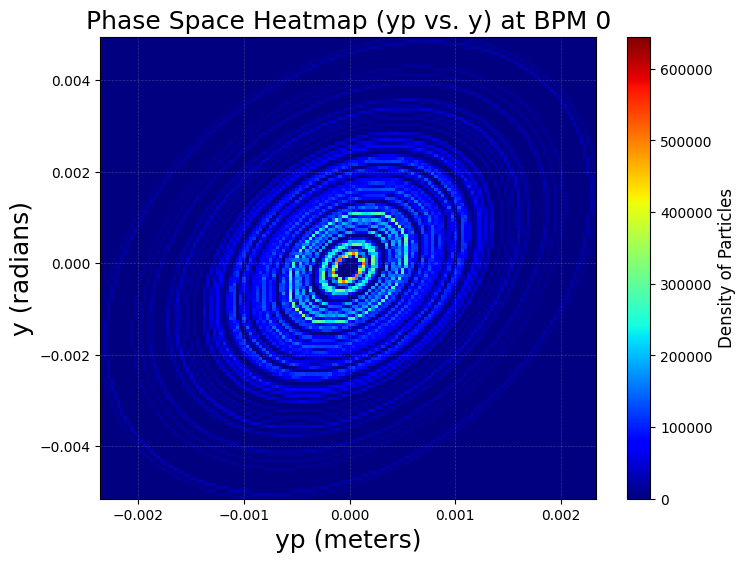

In [33]:
sim_with_error.plot_phase_space_diagram(first_axis='yp', second_axis='y', plot_all=False, start_idx=0 ,save_label='y_yp_test_with_error', fontsize=18)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


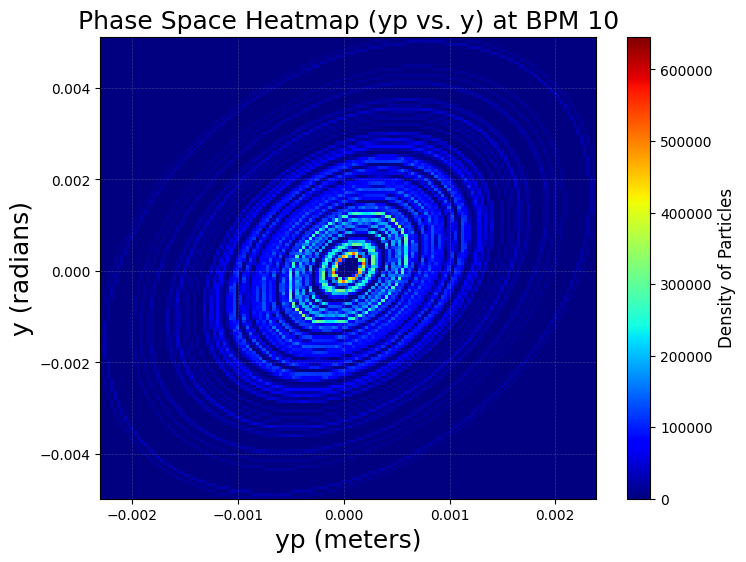

In [34]:
sim_with_error.plot_phase_space_diagram(first_axis='yp', second_axis='y', plot_all=False, cell_idx=10, start_idx=0 ,save_label='y_yp_test_with_error', fontsize=18)

## FFT & Tunes Analysis

In [28]:
sim_no_error.bpm_readings['x'].shape

(1, 10, 8)

In [29]:
sim_no_error.bpm_readings['x'][0, :, 0]

array([-5.02322800e-03,  5.18204534e-03, -5.12884610e-03,  4.86580686e-03,
       -4.40368952e-03,  3.76140099e-03, -2.96521969e-03,  2.04772031e-03,
       -1.04644115e-03,  2.34821771e-06])

In [30]:
sim_no_error.bpm_readings['y'].shape

(1, 10, 8)

The first revolution; BPMs 0-9 (10 is not included)
The data is identical for both the simulations, with and w/o error,   
because the quad that has the error is in the 10th FODO cell.   

In [57]:
sim_no_error.bpm_readings['y'][:, 0:1, 0:10].mean(), sim_no_error.bpm_readings['y'][:, 0:1, 0:10].std()

(-6.269114819859413e-06, 0.0016138889325536293)

In [56]:
sim_with_error.bpm_readings['y'][:, 0:1, 0:10].mean(), sim_with_error.bpm_readings['y'][:, 0:1, 0:10].std()

(-6.269114819859413e-06, 0.0016138889325536293)

The first revolution; BPMs 0-10 (10 is included; 11 is excluded).  
when including the the BPM data which has the quad with error,   
we see the the simulation data with vs w/o erorr starts to deviate and are different.  

In [58]:
sim_no_error.bpm_readings['y'][:, 0:1, 0:11].mean(), sim_no_error.bpm_readings['y'][:, 0:1, 0:11].std()

(1.11429361686947e-05, 0.0016152154707967145)

In [59]:
sim_with_error.bpm_readings['y'][:, 0:1, 0:11].mean(), sim_with_error.bpm_readings['y'][:, 0:1, 0:11].std()

(2.5540067919403767e-05, 0.0016174076366118006)

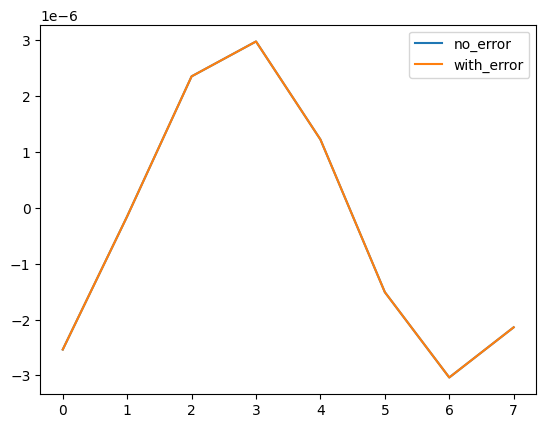

In [26]:
plot(sim_no_error.bpm_readings['y'][:, :, 0:10].mean(axis=0).mean(axis=0))
plot(sim_with_error.bpm_readings['y'][:, :, 0:10].mean(axis=0).mean(axis=0))
legend(['no_error', 'with_error'])

In [27]:
sim_no_error.bpm_readings['x'].shape

(1, 100, 8)

(80,)

In [40]:
np.ravel

<function ravel at 0x7f54b193fef0>

In [ ]:
sim_no_error.bpm_readings['x'][0, :, :]

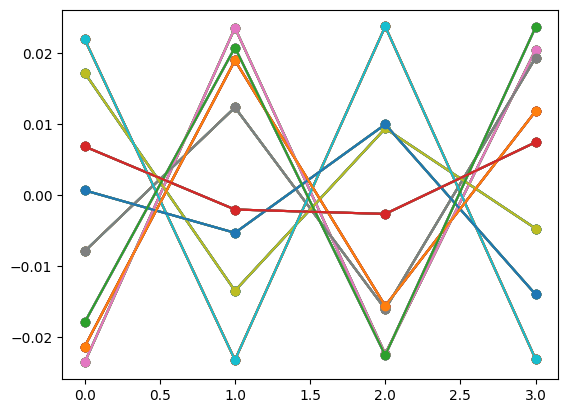

In [78]:
nb_bpms = sim_no_error.bpm_readings['x'].shape[2]
for i in range(nb_bpms):
    plot(sim_no_error.bpm_readings['x'][0, 0:4, :], 'o-')


In [28]:
sim_no_error.bpm_readings['x'].shape

(1, 100, 8)

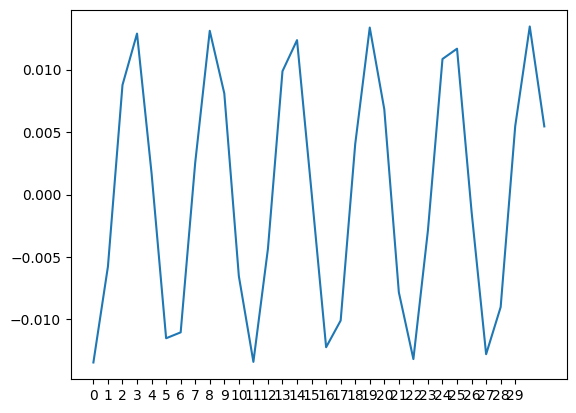

In [29]:
plot(sim_no_error.bpm_readings['x'].ravel(order='C')[:4*8])
plt.xticks(np.arange(30));

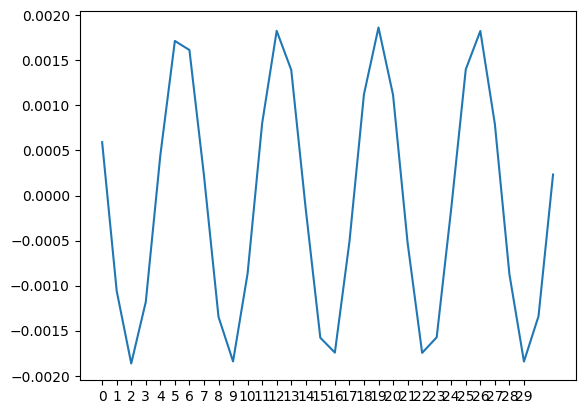

In [32]:
plot(sim_no_error.bpm_readings['y'].ravel(order='C')[:4*8])
plt.xticks(np.arange(30));

In [36]:
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

def tune_from_fft(data):
    # Step 2: Perform FFT on the uniformly sampled data
    N = len(data)  # Number of samples
    T = 1/8  # Sampling interval
    yf = fft(data)  # FFT of y
    xf = fftfreq(N, T)[:N//2]  # Corresponding frequency bins
    
    plt.figure()
    plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), label='FFT of y(x)')
    # plt.plot(xf, 2.0/N * np.abs(yf[:N//2]), label='FFT of y(x)')
    plt.show()
    
    
    
    # Assume xf and yf are already defined
    # xf: Frequency values
    # yf: FFT values (complex)
    
    # Compute the magnitude spectrum
    magnitude = 2.0 / N * np.abs(yf[:N//2])  # Ensure magnitude is for positive frequencies
    
    # Find peaks in the magnitude spectrum
    # peaks, _ = find_peaks(magnitude, height=0.0001)  # Adjust height threshold as needed
    peaks, _ = find_peaks(magnitude)  # Adjust height threshold as needed
    peak_frequencies = xf[peaks]
    peak_magnitudes = magnitude[peaks]
    
    # Print the peak frequencies and magnitudes
    for freq, mag in zip(peak_frequencies, peak_magnitudes):
        print(f"Tune from simulation data: {freq:.4f}")

    max_tne = peak_frequencies[np.argmax(peak_frequencies)]
    print(f"\t max tune: {max_tne}")


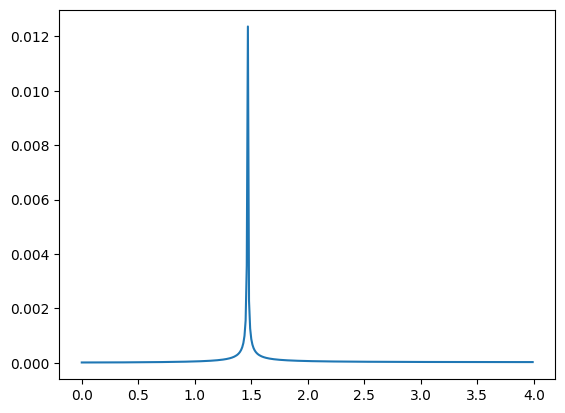

Tune from simulation data: 1.4700
	 max tune: 1.47


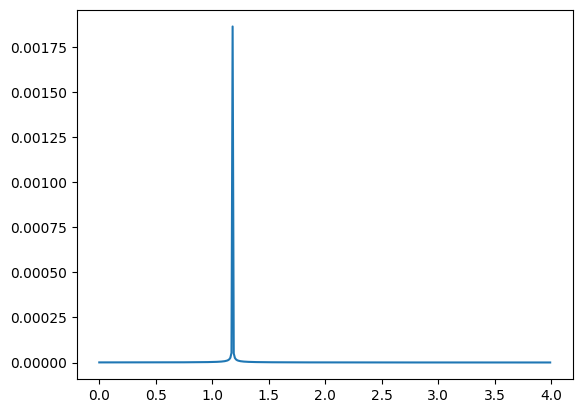

Tune from simulation data: 1.1800
	 max tune: 1.18


In [37]:
tune_x_from_fft = tune_from_fft(sim_no_error.bpm_readings['x'][0, :].ravel(order='C'))
tune_y_from_fft = tune_from_fft(sim_no_error.bpm_readings['y'][0, :].ravel(order='C'))


In [50]:
np.save("bpm_readings_10k_revs", sim_no_error.bpm_readings)

In [51]:
x = np.load("bpm_readings_10k_revs.npy", allow_pickle=True)
data_dict = x.item()
data_dict.keys()

dict_keys(['x', 'y', 'xp', 'yp', 's'])

In [52]:
! pwd


/home/aribra/jnps/thesis/public_repo/lattice_correction_net/notebooks


In [54]:
data_dict['x'].shape

(1, 10000, 8)

In [62]:
data_dict['s']

0.0

In [294]:
import os
import torch
from pathlib import Path
from pylab import *

home = Path("/home/aribra/jnps/thesis/public_repo/lattice_correction_net/data/")

# tag = Path("Sim100_6000turns_5parts_FODOErr-123457-136-_avgFalse_tgtquad_misalign_deltas_1")

# tag = Path("Sim10_6000turns_5parts_FODOErr-1--_avgFalse_tgtquad_misalign_deltas_1")

# tag = Path('Sim5_6000turns_5parts_FODOErr-1--_avgFalse_tgtquad_misalign_deltas_1')

# tag = Path('Sim5_6000turns_5parts_FODOErr-1--_avgFalse_tgtquad_misalign_deltas_5')

tag = Path('Sim5_6000turns_5parts_FODOErr-1--_avgFalse_tgtquad_misalign_deltas_6')


data_entity = Path("input_tensors-final.pt")

full_path = home / tag / data_entity

In [295]:
x_100x = torch.load(str(full_path))

/tmp/ipykernel_1361216/3895694041.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  x_100x = torch.load(str(full_path))


In [296]:
x_100x.shape

torch.Size([10, 6000, 8, 2])

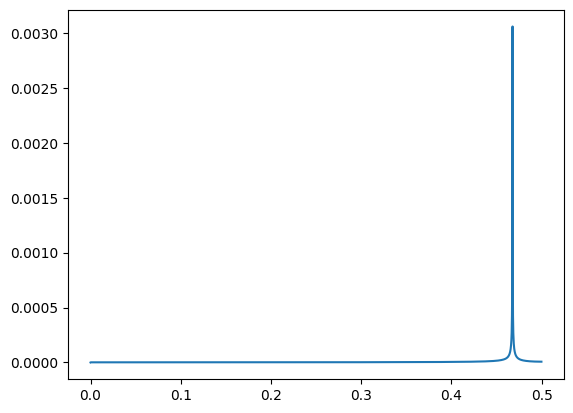

Tune from simulation data: 0.0002
Tune from simulation data: 0.0005
Tune from simulation data: 0.0015
Tune from simulation data: 0.4678
	 max tune: 0.4678333333333333


In [326]:
# X-axis
tune_from_fft(x_100x[4, :, 3, 0])


In [217]:
x_100x.shape

torch.Size([20, 500, 8, 2])

## Plot timeseries

sim_idx=4


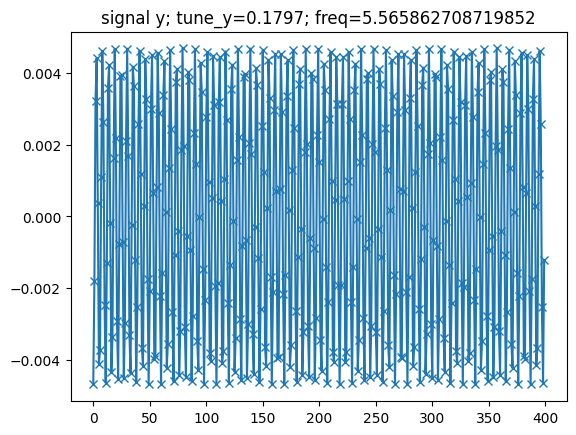

In [319]:
nb_revs = 50
sim_idx = 4 # np.random.randint(100)
print(f"sim_idx={sim_idx}")
data_axis = 1
data_label = 'x' if data_axis == 0 else 'y'

# signal_y = x_100x [sim_idx, :nb_revs, :, data_axis].numpy().ravel(order='C')

in_data = x_100x[sim_idx, :, :, data_axis].numpy()  # y plane

# tune_y = get_tune(signal_y)

Q_fft, Q_per_bpm = compute_global_tune(in_data)

# end_of_revs = np.linspace(8, signal_y.shape[0], signal_y.shape[0] // 8) - 1
# end_of_revs = end_of_revs.astype(int)

plot(signal_y, '-x')
# plot(end_of_revs, signal_y[end_of_revs], '-or')
title(f"signal {data_label}; tune_{data_label}={Q_fft:.4f}; freq={1/Q_fft}")
show()

In [ ]:
# from one-turn matrix
#     'Qx': 0.17971989927789359
#     'Qy': 0.4677523855413338

### Twiss parameters

In [33]:
alpha_x, beta_x, epsilon_x, alpha_y, beta_y, epsilon_y = sim_no_error.compute_twiss_parameters()

In [34]:
print(f'alpha_x: {alpha_x}, beta_x: {beta_x}, epsilon_x: {epsilon_x}, \n alpha_y: {alpha_y}, beta_y: {beta_y}, epsilon_y: {epsilon_y}')

alpha_x: 1.3231539413736924, beta_x: 22.070265557828495, epsilon_x: 0.12463539894276571, 
 alpha_y: -0.6182915394144198, beta_y: 10.313129893916766, epsilon_y: 0.13403151535275418


In [146]:
peaks

array([], dtype=int64)

In [45]:
sim_with_error.figs_save_dir

'figs'

In [46]:
sim_no_error.n_turns

5

In [47]:
4 * 4

16

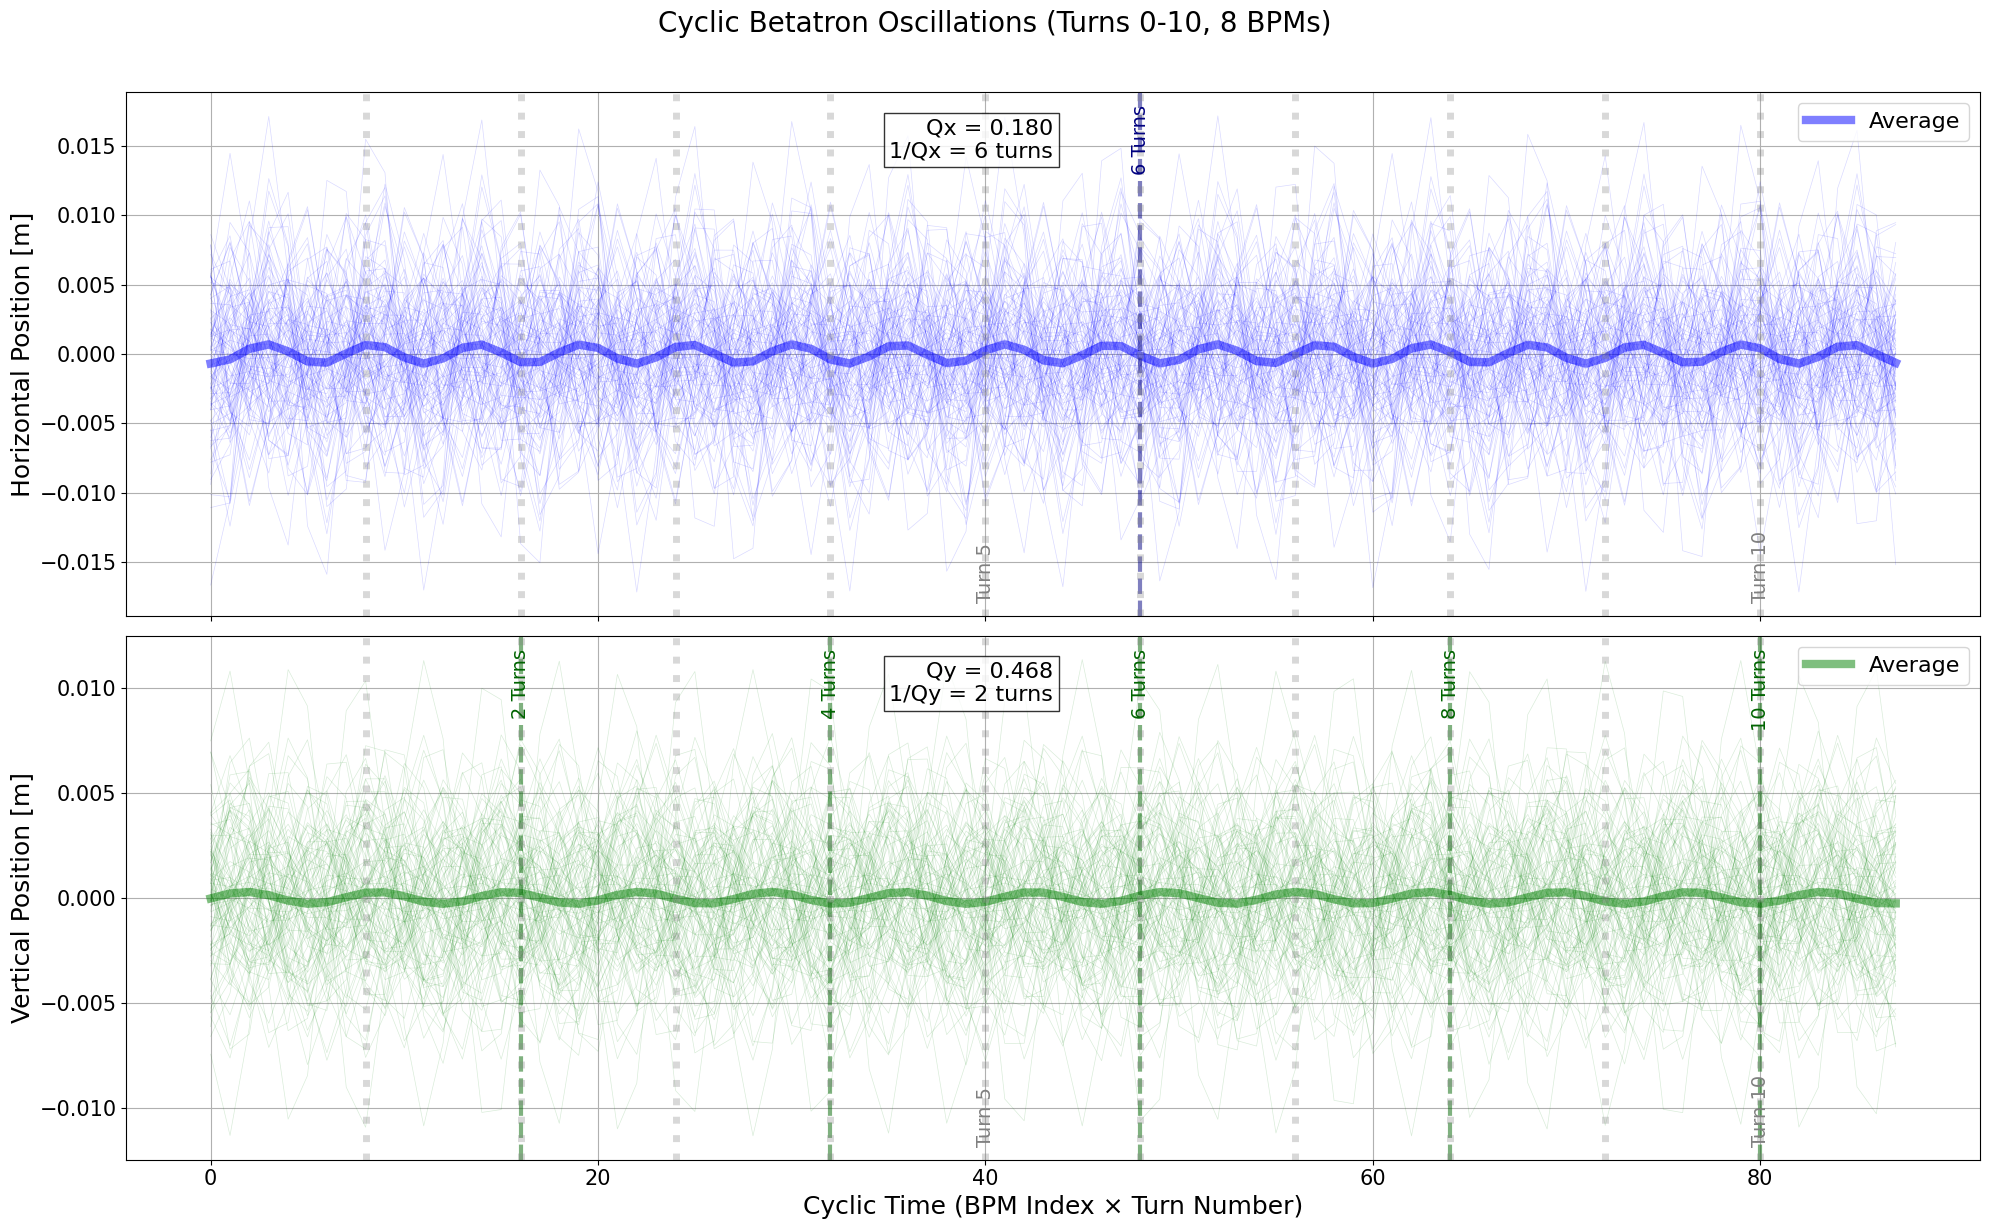

In [28]:
sim_no_error.plot_betatron_oscillations_TURN_FLATTEN(
    n_particles=100,
    start_turn=0, 
    end_turn=10,
    save_label='no_error',
)


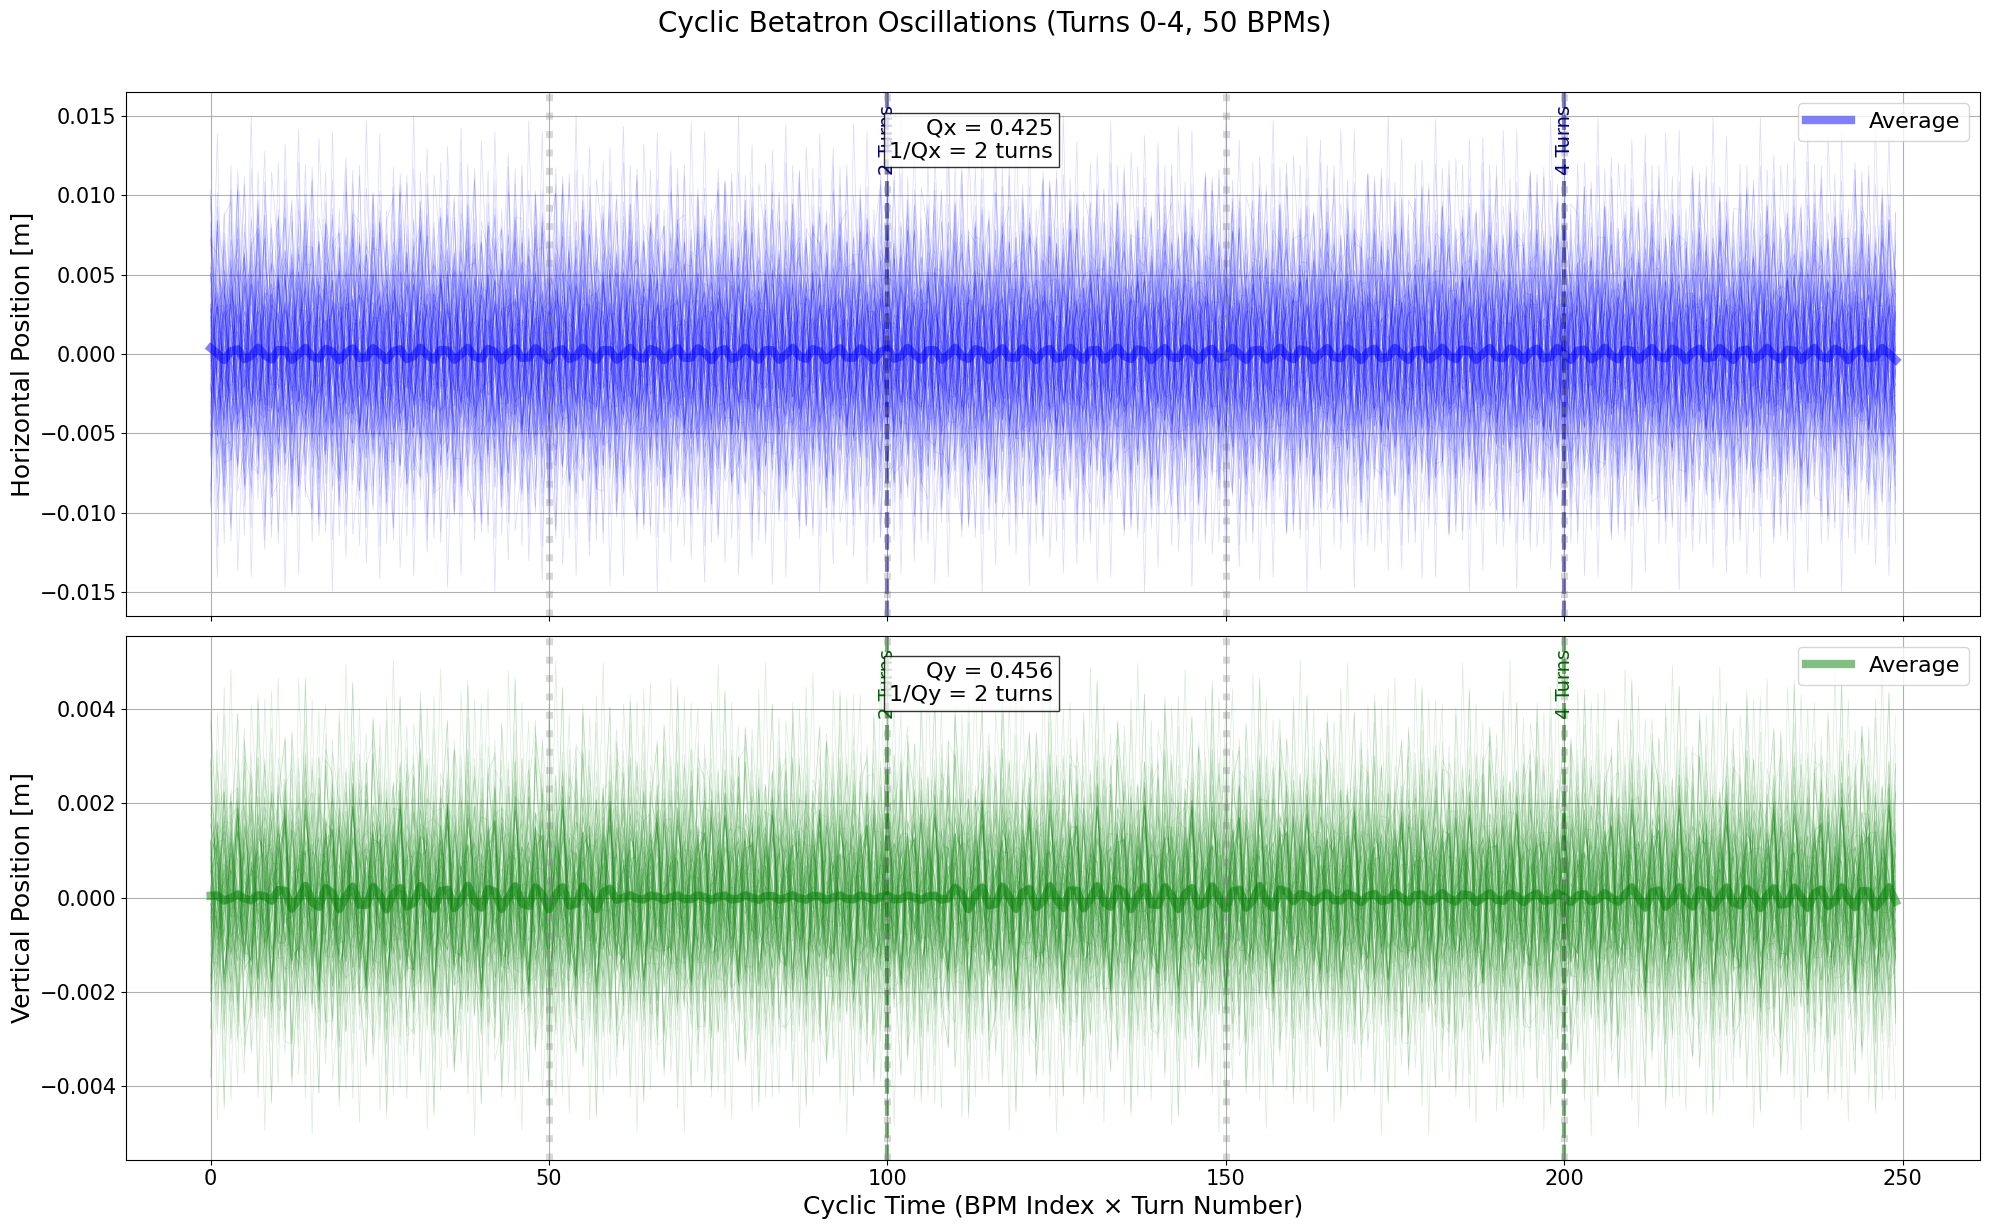

In [97]:
sim_with_error.plot_betatron_oscillations_TURN_FLATTEN(
    n_particles=100,
    start_turn=0, 
    end_turn=4,
    save_label='with_error',
)


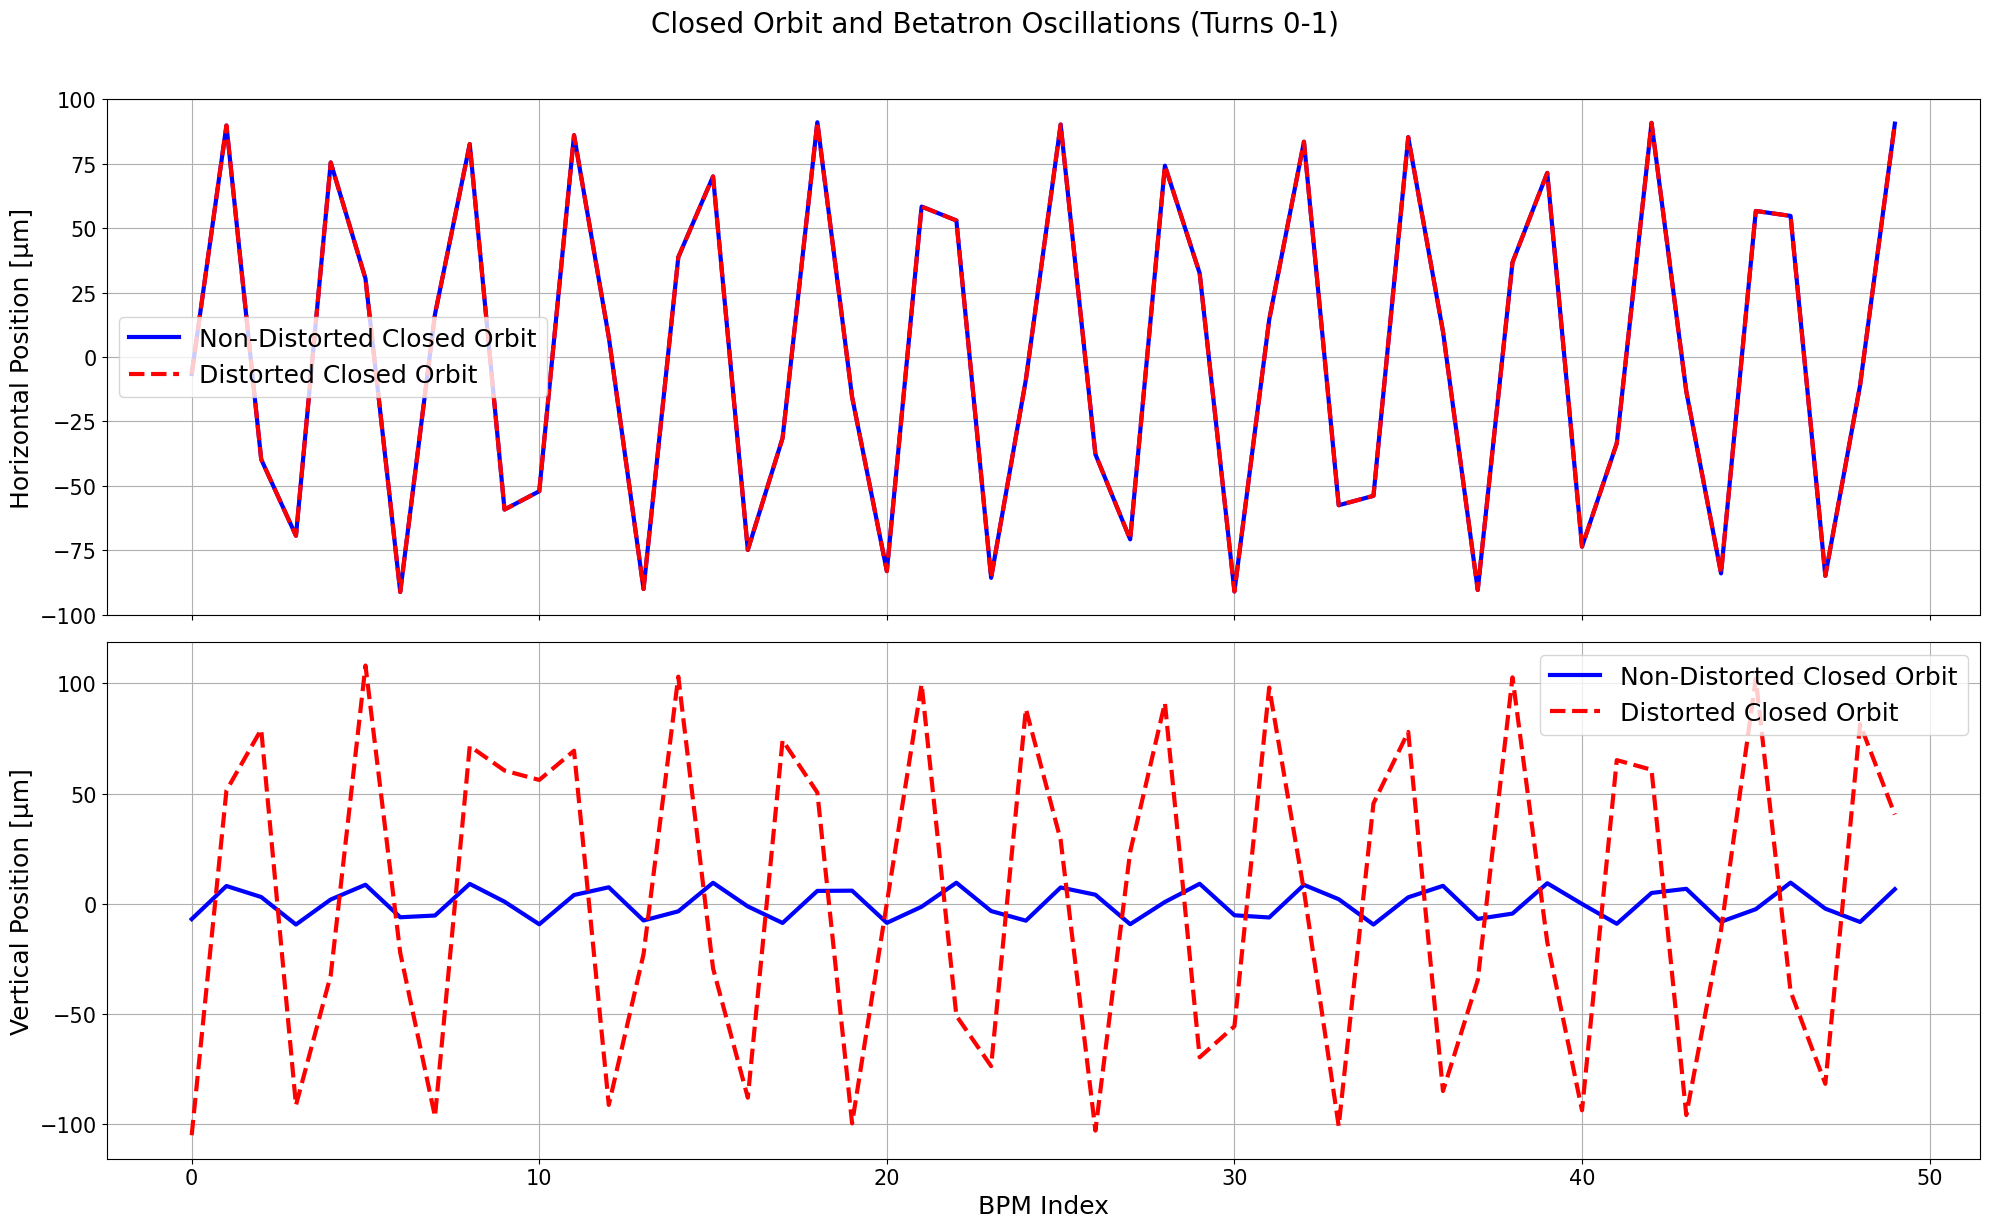

In [100]:
sim_no_error.plot_betatron_oscillations_BPM(
    sim_with_error,
    n_particles=0,
    start_turn=0, 
    end_turn=1,
    save_label='comparison',
)


### tunes from FFT 

In [307]:
def get_tune(signal):

    y_signal = signal
    N = len(y_signal)
    fft_vals = np.fft.fft(y_signal)  # remove DC component
    freqs = np.fft.fftfreq(N, d=1)  # assuming 1 turn per sample
    power = np.abs(fft_vals)**2
    half = N // 2
    freqs = freqs[:half]
    power = power[:half]
    tune_index = np.argmax(power)
    tune = freqs[tune_index]
    return tune


def compute_global_tune(bpm_data):
    """
    Compute fractional tune from multiple BPM signals.

    Parameters
    ----------
    bpm_data : ndarray, shape [n_turns, n_BPMs]
        Beam positions per turn at different BPMs.

    Returns
    -------
    tune_avg : float
        Average tune across BPMs.
    tunes_per_bpm : ndarray
        Tune per BPM.
    """
    n_turns, n_bpms = bpm_data.shape
    tunes = np.zeros(n_bpms)

    for i in range(n_bpms):
        y_signal = bpm_data[:, i]
        y_signal -= np.mean(y_signal)  # remove DC
        fft_vals = np.fft.fft(y_signal)
        freqs = np.fft.fftfreq(n_turns, d=1.0)
        half = n_turns // 2
        freqs = freqs[:half]
        power = np.abs(fft_vals[:half])**2
        tune_idx = np.argmax(power[1:]) + 1  # skip DC
        tunes[i] = np.abs(freqs[tune_idx] % 1.0)

    tune_avg = np.mean(tunes)
    return tune_avg, tunes


In [247]:
sim_no_error.bpm_readings['y'].mean(axis=0).shape

(6000, 8)

In [233]:
sim_no_error.Qx, sim_no_error.Qy

(0.17971989927789359, 0.4677523855413338)

In [234]:
signal.shape[0] / 8

34.0

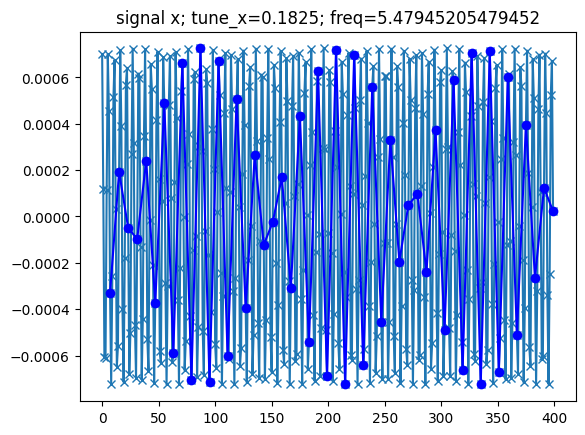

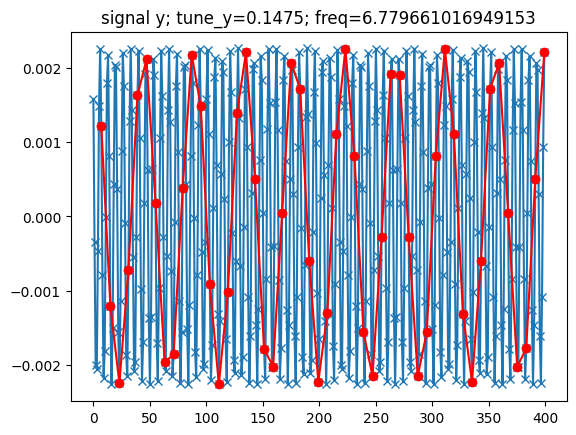

In [235]:
nb_revs = 50
signal_x = sim_no_error.bpm_readings['x'].mean(axis=0)[:nb_revs, :].ravel(order='C')
signal_y = sim_no_error.bpm_readings['y'].mean(axis=0)[:nb_revs:, :].ravel(order='C')

tune_x = get_tune(signal_x)
tune_y = get_tune(signal_y)

end_of_revs = np.linspace(8, signal_x.shape[0], signal_x.shape[0] // 8) - 1
end_of_revs = end_of_revs.astype(int)

plot(signal_x, '-x')
plot(end_of_revs, signal_x[end_of_revs], '-ob')
title(f"signal x; tune_x={tune_x:.4f}; freq={1/tune_x}")
show()

plot(signal_y, '-x')
plot(end_of_revs, signal_y[end_of_revs], '-or')
title(f"signal y; tune_y={tune_y:.4f}; freq={1/tune_y}")
show()

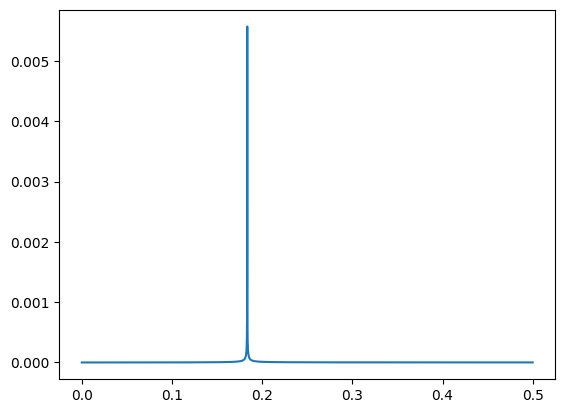

Tune from simulation data: 0.1835


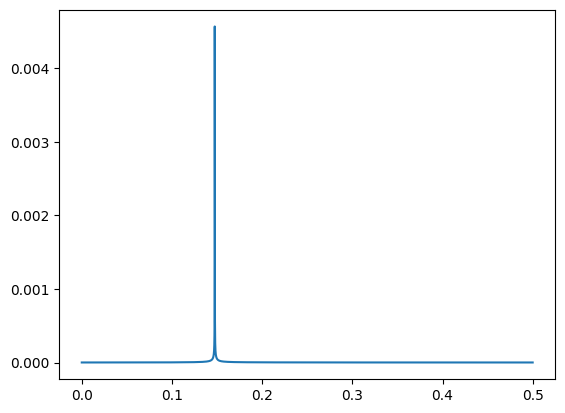

Tune from simulation data: 0.1474


In [246]:
tune_x_from_fft = tune_from_fft(sim_no_error.bpm_readings['x'][0, :2000, :].flatten())
tune_y_from_fft = tune_from_fft(sim_no_error.bpm_readings['y'][0, :2000, :].flatten())

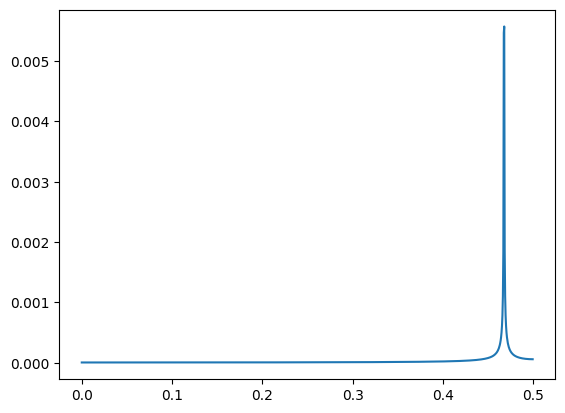

Tune from simulation data: 0.4680


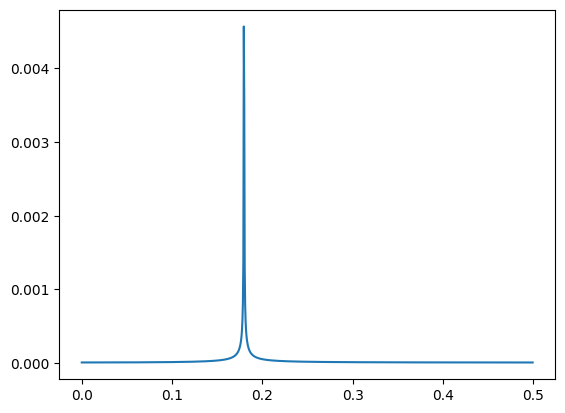

Tune from simulation data: 0.1795


In [245]:
tune_x_from_fft = tune_from_fft(sim_no_error.bpm_readings['x'][0, :2000, 0])
tune_y_from_fft = tune_from_fft(sim_no_error.bpm_readings['y'][0, :2000, 0])

In [250]:
sim_no_error.bpm_readings['x'][0, :, 0].shape

(6000,)

(101,)


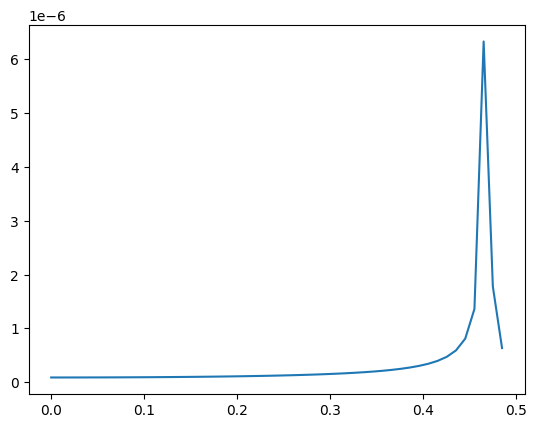

Tune from simulation data: 0.4653


In [264]:
bad_run_avg = running_average_numpy(sim_no_error.bpm_readings['x'][0, 5500:6000, 0], 6000 - 5500 - 100)
print(bad_run_avg.shape)
tune_from_fft(bad_run_avg)

In [ ]:
bad_run_avg

In [252]:
def running_average_numpy(data, window_size):
    data = np.asarray(data)
    if window_size <= 0:
        raise ValueError("Window size must be positive.")
    if window_size > len(data):
        raise ValueError("Window size cannot be larger than the data length.")

    window = np.ones(window_size) / window_size
    running_avg = np.convolve(data, window, mode='valid')
    return running_avg


(6000,)

In [148]:
end_of_revs

array([  7,  15,  23,  31,  39,  47,  55,  63,  71,  79,  87,  95, 103,
       111, 119, 127, 135, 143, 151, 159, 167, 175, 183, 191, 199, 207,
       215, 223, 231, 239, 247, 255, 263, 271, 279, 287, 295, 303, 311,
       319, 327, 335, 343, 351, 359, 367, 375, 383, 391, 399, 407, 415,
       423, 431, 439, 447, 455, 463, 471, 479, 487, 495, 503, 511, 519,
       527, 535, 543, 551, 559, 567, 575, 583, 591, 599, 607, 615, 623,
       631, 639, 647, 655, 663, 671, 679, 687, 695, 703, 711, 719, 727,
       735, 743, 751, 759, 767, 775, 783, 791, 799])

(0.17957422748682422, 0.4677684656420541)

In [150]:
1/sim_with_error.Qx, 1/sim_with_error.Qy

(5.568727840265232, 2.13780977866349)

In [181]:
# xs_all_bpms = sim_data['input_tensors'][0, :10, :, 0].ravel()



    # print("Betatron tune (X):", tune)
    # print(1 / tune)
# print(y_signal)
# ys_all_bpms

In [1]:

sim_no_error.plot_comparison(
    sim_with_error, 
    cell_idx=2, 
    start_idx=0, 
    end_idx=2,
    viz_start_idx=0,
    viz_end_idx=2, 
    save_label="sim_test", 
    window_size=1, 
    plot_all=True, 
    extra_title="All BPMs")


NameError: name 'sim_no_error' is not defined

In [21]:
-1.75842232e-05

-1.75842232e-05

In [22]:
0.5949649+0.80375168j

(0.5949649+0.80375168j)

In [23]:
 [[ 3.32244410e-01, -6.33731995e+00, -1.01349045e-17,  4.47729428e-17],
 [ 5.70374284e-02,  1.92188506e+00,  1.43910248e-17, -6.38588592e-17],
 [-3.12002922e-18,  4.13583235e-17,  7.37394901e-01, -3.85271430e+00],
 [ 5.41646199e-18, -7.27206950e-17,  4.37603267e-01, -9.30248316e-01]]

[[0.33224441, -6.33731995, -1.01349045e-17, 4.47729428e-17],
 [0.0570374284, 1.92188506, 1.43910248e-17, -6.38588592e-17],
 [-3.12002922e-18, 4.13583235e-17, 0.737394901, -3.8527143],
 [5.41646199e-18, -7.2720695e-17, 0.437603267, -0.930248316]]

In [ ]:
7.37394901e-01

In [ ]:
-1.75842232e-05

  Quadrupole Tilt Error 1: FODO Cell 3, Defocusing, Tilt Angle = np.pi/2 rad (90 degrees)


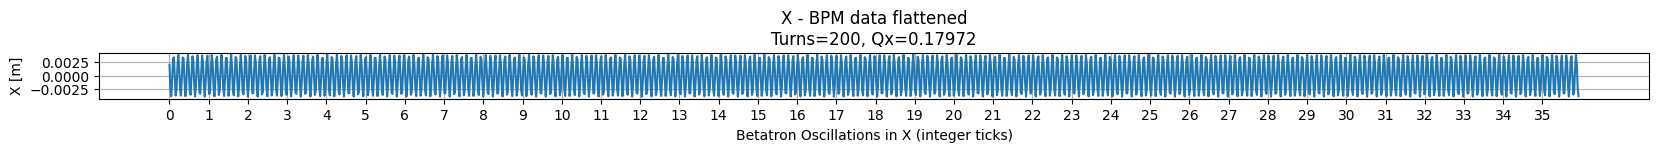

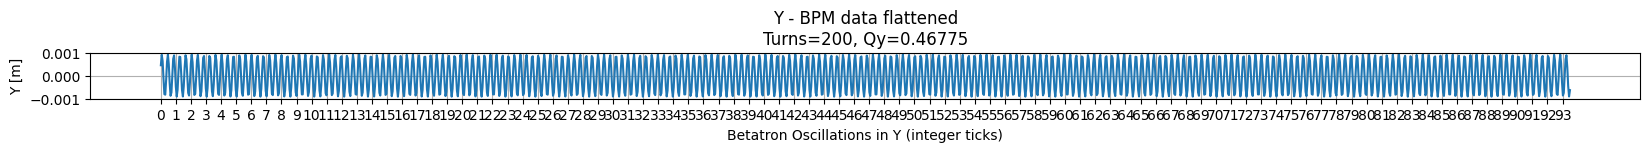

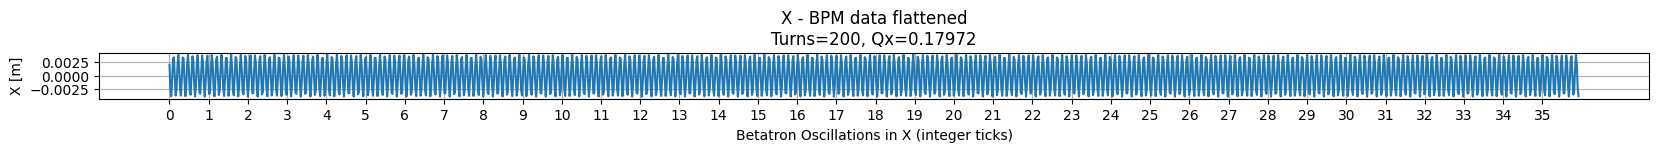

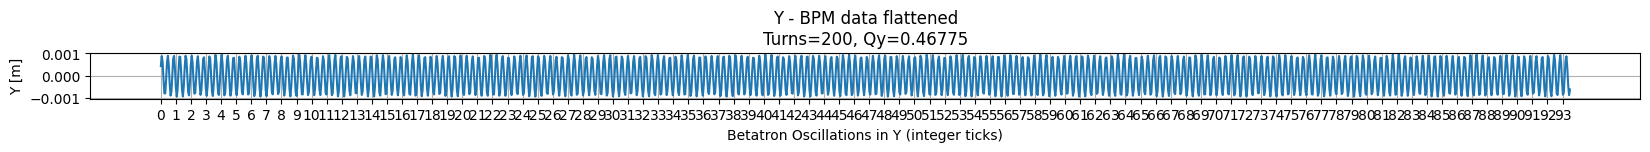

In [48]:
particle_idx = 0
start_idx = 4000
end_idx = 4200


print("  Quadrupole Tilt Error 1: FODO Cell 3, Defocusing, Tilt Angle = np.pi/2 rad (90 degrees)")
sim_no_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)
sim_with_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)

  Quadrupole Tilt Error 1: FODO Cell 3, Defocusing, Tilt Angle = -0.5235987755982988 rad (30 degrees)


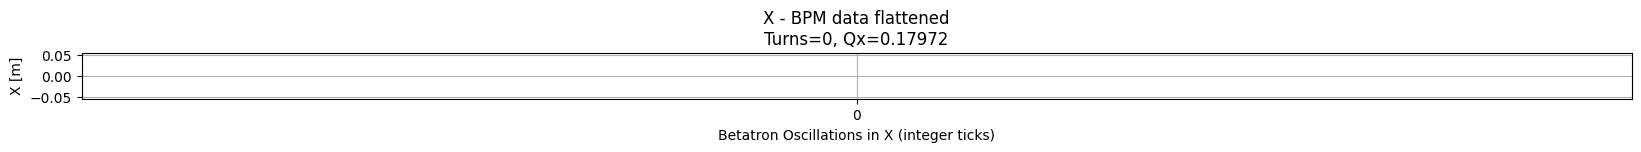

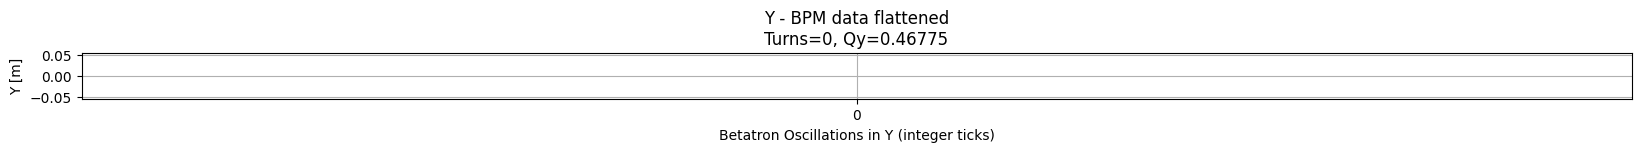

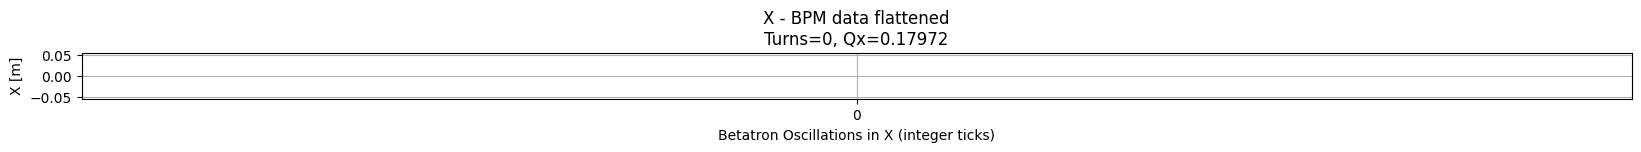

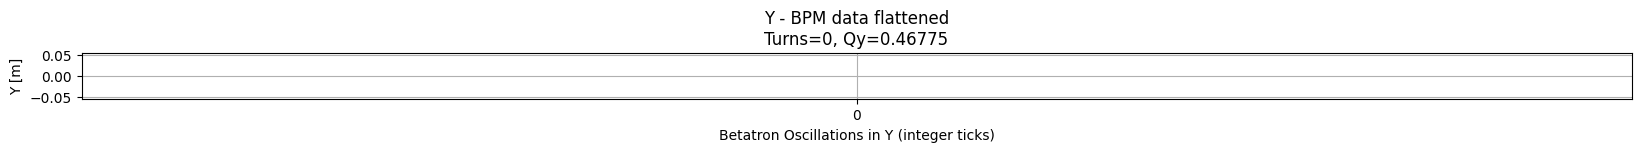

In [46]:
particle_idx = 0
start_idx = 7000
end_idx = 8000


print("  Quadrupole Tilt Error 1: FODO Cell 3, Defocusing, Tilt Angle = -0.5235987755982988 rad (30 degrees)")
sim_no_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)
sim_with_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)

In [ ]:
viz_end_idx = sim_no_error.n_turns
sim_no_error.plot_comparison(sim_with_error, cell_idx=0, viz_start_idx=viz_end_idx - 200,
                     viz_end_idx=viz_end_idx, save_label="sim_test", window_size=50, plot_all=True, extra_title="All BPMs")

In [ ]:
sim_no_error.plot_phase_space_diagram(first_axis='x', second_axis='y', cell_idx=4, plot_all=False)

In [ ]:
sim_no_error.plot_phase_space_diagram(first_axis='x', second_axis='xp', cell_idx=i, plot_all=True)

In [ ]:
sim_no_error.plot_phase_space_diagram(first_axis='y', second_axis='yp', cell_idx=i, plot_all=True)

In [ ]:
sim_with_error.plot_phase_space_diagram(first_axis='x', second_axis='xp', cell_idx=i, plot_all=True)

In [ ]:
sim_with_error.plot_phase_space_diagram(first_axis='y', second_axis='yp', cell_idx=i, plot_all=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


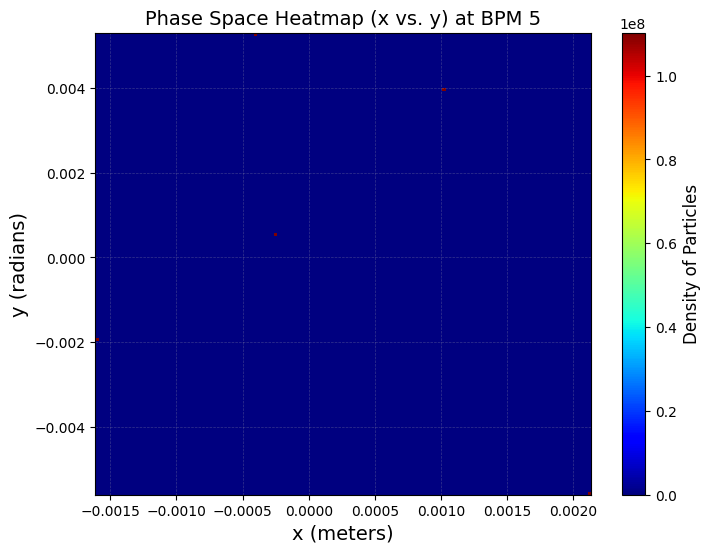

In [53]:
sim_no_error.plot_phase_space_diagram(first_axis='x', second_axis='y', cell_idx=5)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


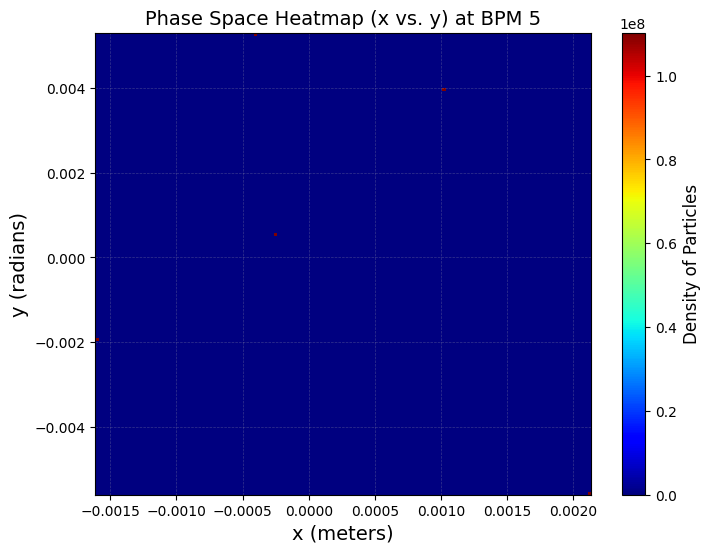

In [55]:
sim_with_error.plot_phase_space_diagram(first_axis='x', second_axis='y', cell_idx=5)

In [ ]:
sim_with_error.plot_phase_space_diagram(first_axis='xp', second_axis='x', cell_idx=0)

In [54]:
sim_no_error.compare_bpm_signal_vs_bpm_number(
    other_simulator=sim_with_error,
    turn=99,
    plane='vertical',
    average_over_particles=True,
    plot_difference=True
)


ValueError: Requested turn 99 is out of range for at least one simulator.

plot_bpm_comparison_last_images()/
	 CoM No error: X = 4.7575821931943504e-07, Y = -3.441036754224712e-07
	 CoM With Error: X = 4.7575821931943504e-07, Y = -3.441036754224712e-07
----
	 f'ΔX = 0.0000000 m, 0.00 micron
	 f'ΔY = 0.0000000 m, 0.00 micron
----


/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2318: UserWarning: Legend does not support handles for QuadMesh instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  legend = plt.legend(facecolor='gray', edgecolor='white', framealpha=0.7)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


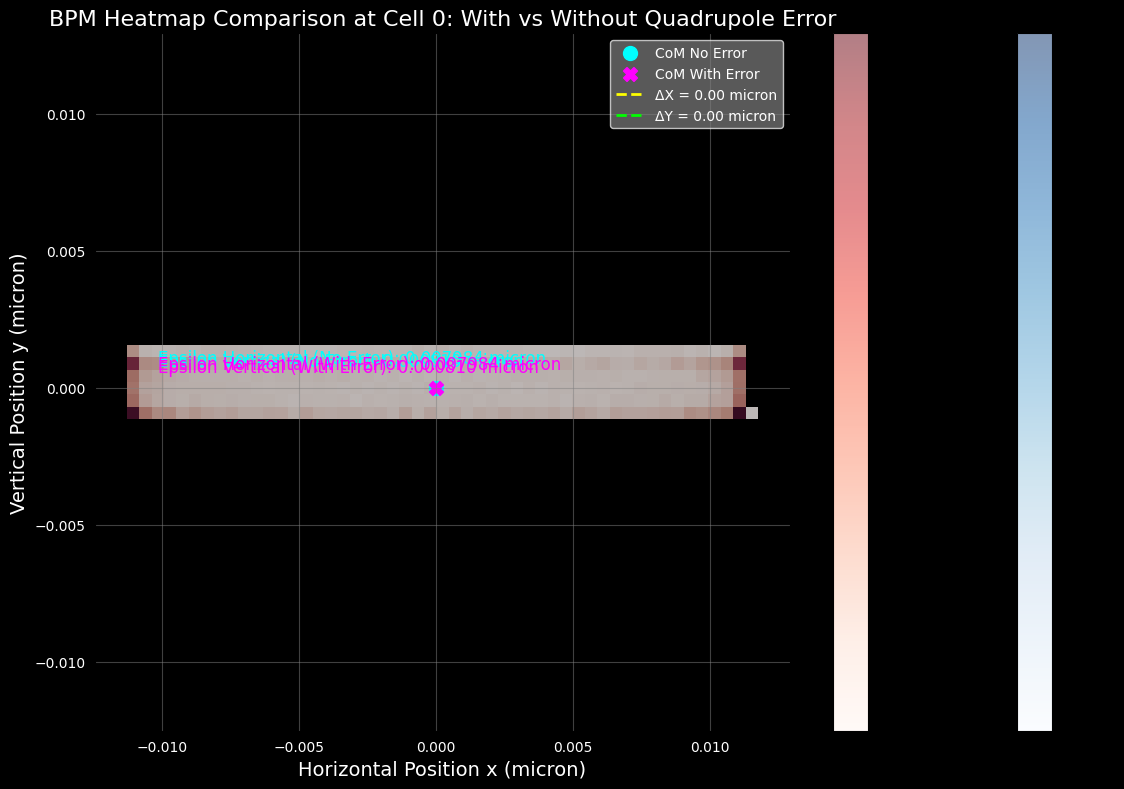

AttributeError: 'SynchrotronSimulator' object has no attribute 'plot_comparison'

In [97]:
cell_idx = 0
sim_no_error.plot_bpm_comparison_last_images(sim_no_error, sim_with_error, cell_idx=cell_idx, particles='all_mean')
viz_start_idx = sim_no_error.n_turns - 100
viz_end_idx = sim_no_error.n_turns
sim_no_error.plot_comparison(sim_with_error, cell_idx=cell_idx, viz_start_idx=viz_start_idx, viz_end_idx=viz_end_idx)

In [ ]:
cell_idx = 0
sim_no_error.plot_bpm_comparison_last_images(sim_no_error, sim_with_error, cell_idx=cell_idx, particles='all_mean')
viz_start_idx = sim_no_error.n_turns - 100
viz_end_idx = sim_no_error.n_turns
sim_no_error.plot_comparison(sim_with_error, cell_idx=cell_idx, viz_start_idx=viz_start_idx, viz_end_idx=viz_end_idx)

In [57]:

total_elements_no_error = len(sim_no_error.M_lattice_4x4)
total_elements_with_error = len(sim_with_error.M_lattice_4x4)

total_elements_no_error, total_elements_with_error

(64, 64)

In [58]:
sim_no_error.M_lattice_4x4[12]

array([[1.       , 0.7817477, 0.       , 0.       ],
       [0.       , 1.       , 0.       , 0.       ],
       [0.       , 0.       , 1.       , 0.7817477],
       [0.       , 0.       , 0.       , 1.       ]])

In [59]:
sim_with_error.M_lattice_4x4[13]

array([[ 0.95694034,  5.80569355,  0.        ,  0.        ],
       [-0.01451423,  0.95694034,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  1.        ,  5.89048623],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [60]:
sim_no_error.n_turns

5

In [61]:
sim_no_error.bpm_readings['x'].shape

(1, 5, 8)

In [62]:
# sim_no_error.bpm_readings['x']

In [63]:
ix = 0

In [98]:
sim_no_error.bpm_readings['y'][:, :, bpm_ix]

array([[-0.00113007, -0.00065041,  0.00057414, ..., -0.00111838,
        -0.00025541,  0.00090007]])

NameError: name 'ix' is not defined

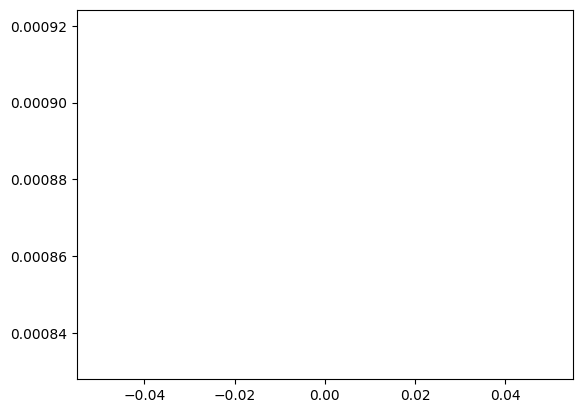

In [44]:
bpm_ix = 0

plt.plot(sim_no_error.bpm_readings['y'][:, 0, bpm_ix].flatten())
plt.plot(sim_no_error.bpm_readings['y'][:, ix, bpm_ix].flatten())
plt.show()
plt.plot(sim_no_error.bpm_readings['x'][:, 0, bpm_ix].flatten(), sim_no_error.bpm_readings['y'][:, 0, bpm_ix].flatten(), '.')
plt.plot(sim_no_error.bpm_readings['x'][:, ix, bpm_ix].flatten(), sim_no_error.bpm_readings['y'][:, ix, bpm_ix].flatten(), '.')
plt.show()
ix+=1

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


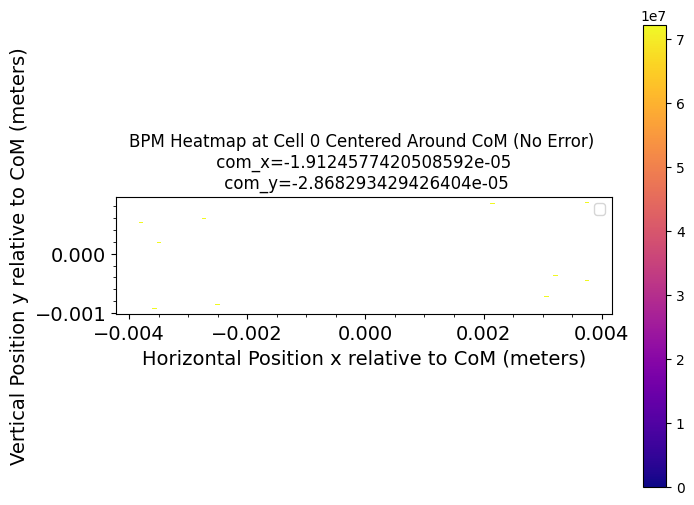

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


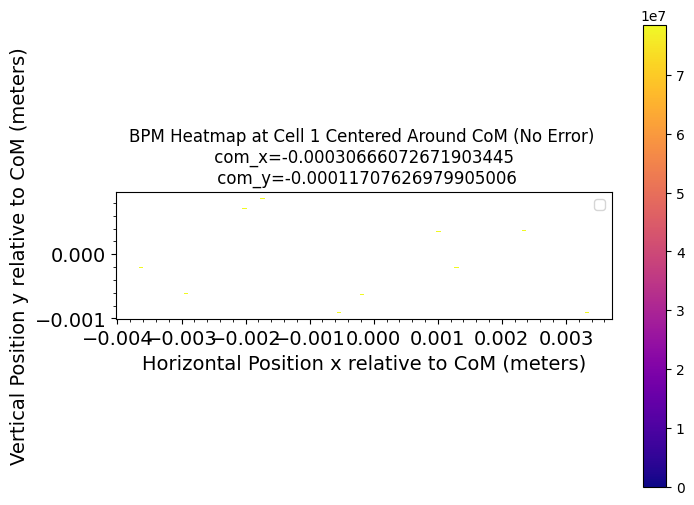

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


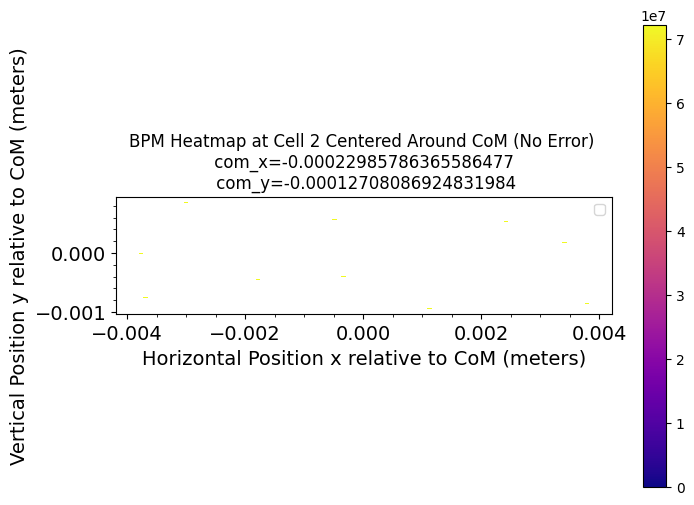

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


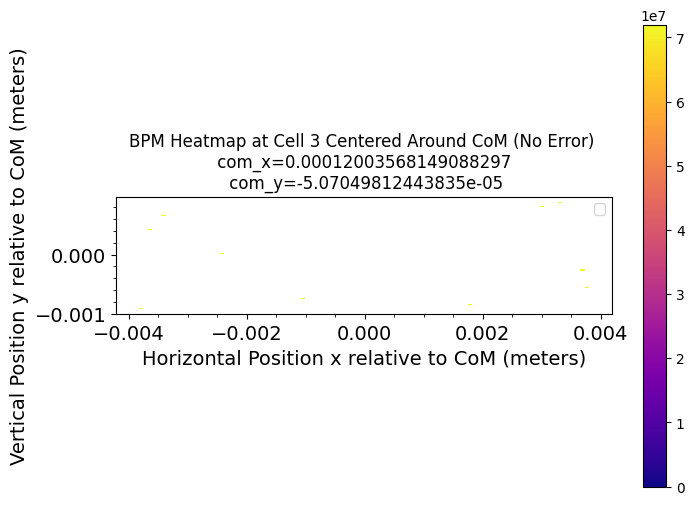

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


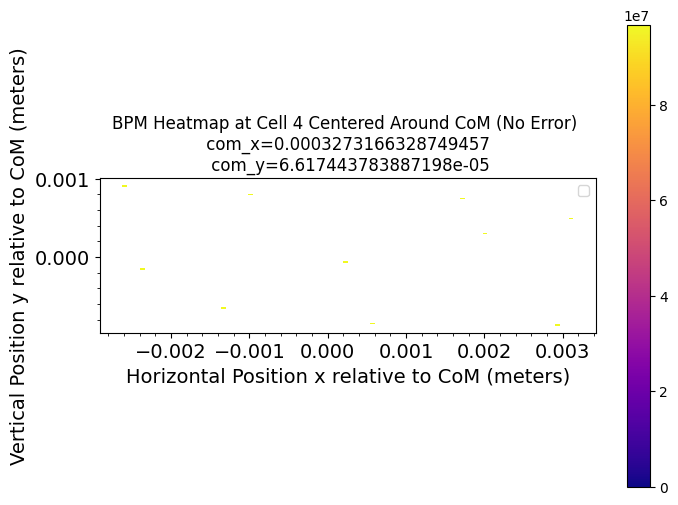

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


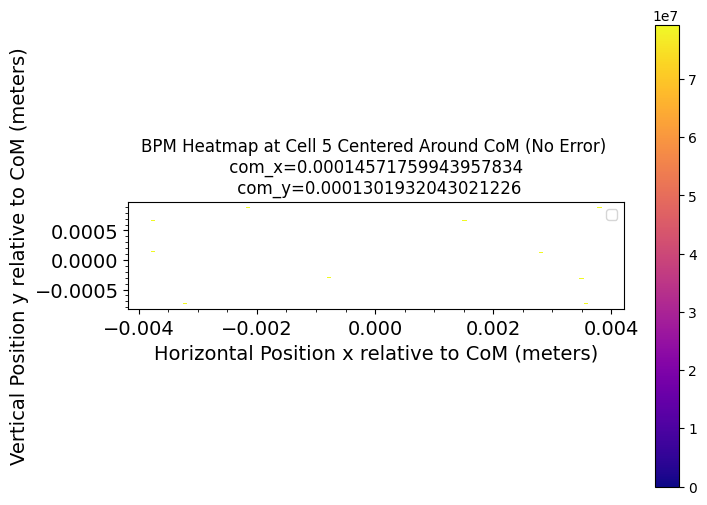

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


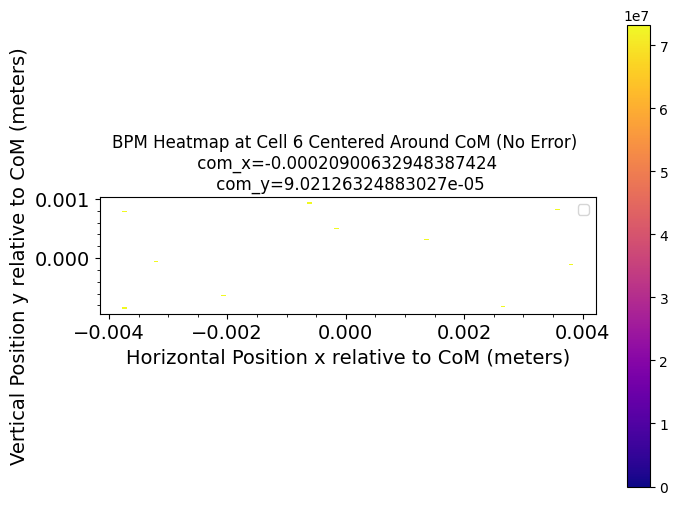

/home/aribra/jnps/thesis/public_repo/lattice_correction_net/synchrotron_simulator_gpu_Dataset_4D.py:2082: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


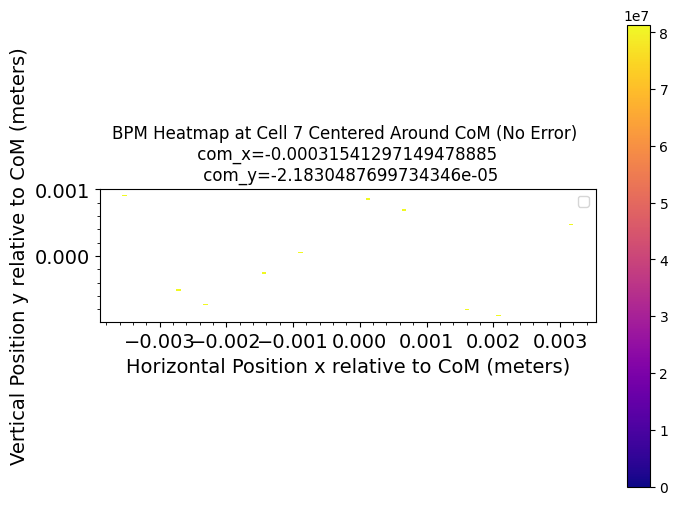

In [43]:
xy_lim = 0.2
plot_xlim = (-xy_lim, xy_lim)
plot_ylim = (-xy_lim, xy_lim)

plot_xlim = None
plot_ylim = None

for i in range(sim_no_error.n_FODO):
    sim_with_error.plot_bpm_heatmaps(
        cell_idx=i, 
        simulation_label='No Error', 
        start_idx=0, 
        end_idx=10,
        plot_xlim=plot_xlim, 
        plot_ylim=plot_ylim)


In [ ]:
from IPython.display import clear_output


xy_lim = 0.1
plot_xlim = (-xy_lim, xy_lim)
plot_ylim = (-xy_lim, xy_lim)

plot_xlim = None
plot_ylim = None

cell_idx = 1
start_idx = 0
for i in range(2):
    sim_with_error.plot_bpm_heatmaps(
        cell_idx=cell_idx, 
        simulation_label='No Error', 
        start_idx=start_idx, 
        end_idx=start_idx+i+1,
        plot_xlim=plot_xlim, 
        plot_ylim=plot_ylim)
    
    clear_output(wait=True)


In [ ]:
sim_no_error.n_turns

In [ ]:
xy_lim = 0.1
plot_xlim = (-xy_lim, xy_lim)
plot_ylim = (-xy_lim, xy_lim)

plot_xlim = None
plot_ylim = None

for i in range(sim_no_error.n_FODO):
    sim_no_error.plot_bpm_heatmaps(
        cell_idx=i, 
        simulation_label='No Error', 
        start_idx=0, 
        end_idx=1500,
        plot_xlim=plot_xlim, 
        plot_ylim=plot_ylim)


In [ ]:
for i in range(sim_no_error.n_FODO):
    particle_idx_start = 0
    particle_idx_end = 10
    start_idx = 0
    end_idx = -1
    cell_idx = i
    

    x_data = sim_no_error.bpm_readings['x'][particle_idx_start:particle_idx_end, start_idx:end_idx, cell_idx]
    xp_data = sim_no_error.bpm_readings['xp'][particle_idx_start:particle_idx_end, start_idx:end_idx, cell_idx]
    
    # x - x'
    plt.figure(figsize=(8,6))
    plt.scatter(x_data, xp_data, alpha=0.7)
    plt.xlabel('x (meters)')
    plt.ylabel("x' (radians)")
    plt.title(f'Phase Space Diagram at BPM {cell_idx}')
    plt.grid(True)
    plt.show()

In [ ]:
particle_idx = 0
start_idx = 1900
end_idx = 2000

sim_no_error.plot_particle_bpm_readings(particle_idx, start_idx, end_idx)

In [ ]:
1 / sim_no_error.Qx

In [ ]:
sim_no_error.n_turns

In [ ]:
xy_lim = 0.005
plot_xlim = (-xy_lim, xy_lim)
plot_ylim = (-xy_lim, xy_lim)

# plot_xlim = None
# plot_ylim = None

sim_no_error.plot_all_bpm_heatmap(start_idx=0, end_idx=-1, plot_ylim=plot_ylim, plot_xlim=plot_xlim)

In [ ]:
help(sim_no_error.plot_all_bpm_heatmap)

In [ ]:
# xy_lim = 0.1
# plot_xlim = (-xy_lim, xy_lim)
# plot_ylim = (-xy_lim, xy_lim)

# # plot_xlim = None
# # plot_ylim = None

# for i in range(sim_with_error.n_FODO):
#     sim_with_error.plot_bpm_heatmaps(cell_idx=i, simulation_label='With Error', plot_xlim=plot_xlim, plot_ylim=plot_ylim)


In [ ]:
# sim_with_error.plot_average_positions()

In [ ]:
for i in range(sim_no_error.n_FODO):
    sim_no_error.plot_last_bpm_image(cell_idx=i)

In [ ]:
# args: plot_xlim=(15, 17), plot_ylim=(-10, -12)
plot_xlim = (-22, -18)
plot_ylim = (5, -5)

# plot_xlim = None
# plot_ylim = None

fig, ax = sim_no_error.plot_particle_trajectory(start_idx=0, end_idx=5, plot_xlim=plot_xlim, plot_ylim=plot_ylim)

In [ ]:
# plot_xlim = (-6, -7)
# plot_ylim = (-15, -10.5)

plot_xlim = None
plot_ylim = None

fig, ax = sim_no_error.plot_particle_trajectory(start_idx=1, end_idx=10, plot_xlim=plot_xlim, plot_ylim=plot_ylim)

### Generate Datasets

In [ ]:
# # Parameters for generate_data
# 'start_rev': 0,
# 'end_rev': 500,
# 'fodo_cell_indices': list(range(8)),  # Indices of BPMs to consider
# 'planes': ['x', 'y'],
# 'cell_idx': 0,
# 'max_revolutions': 100

In [101]:
sim_no_error.bpm_readings['y'].shape

(1, 5000, 8)

In [102]:
simulation_dataset = SimulationDataset(
    bpm_readings_no_error=sim_no_error.bpm_readings,
    bpm_readings_with_error=sim_with_error.bpm_readings,
    bpm_positions=sim_no_error.bpm_positions,
    quadrupole_errors=sim_with_error.quad_errors,
    lattice_reference=sim_no_error.get_lattice_reference()
)

input_tensor, target_tensor = simulation_dataset.generate_data(
    1000, 1500, [7], ['x', 'y']
)

TypeError: SimulationDataset.__init__() missing 3 required positional arguments: 'merged_config', 'quadrupole_tilt_errors', and 'dipole_tilt_errors'

In [103]:
input_tensor.shape

NameError: name 'input_tensor' is not defined

In [104]:
input_tensor[0, :, 0, 0, np.newaxis].shape
# plot(input_tensor[0, :, 0, 0, np.newaxis])

NameError: name 'input_tensor' is not defined

In [105]:
np.concatenate([running_average_numpy(input_tensor[0, :, 0, 0], 100)[..., np.newaxis], running_average_numpy(input_tensor[0, :, 0, 0], 100)[..., np.newaxis]], axis=-1).shape

NameError: name 'running_average_numpy' is not defined

In [ ]:
target_tensor

In [ ]:
def running_average_numpy(data, window_size):
    data = np.asarray(data)
    if window_size <= 0:
        raise ValueError("Window size must be positive.")
    if window_size > len(data):
        raise ValueError("Window size cannot be larger than the data length.")

    # Use 'valid' mode to ensure the window fits completely within the data
    window = np.ones(window_size) / window_size
    running_avg = np.convolve(data, window, mode='valid')
    return running_avg

In [ ]:
plot(sim_no_error.bpm_readings['x'][0, -10:, 0])
plot(sim_with_error.bpm_readings['x'][0, -10:, 0])


In [ ]:
cumu_y = sim_no_error.cumulative_average(input_tensor[0, :, 0, 1])
ravg_y = running_average_numpy(input_tensor[0, :, 0, 1], window_size=100)
plot(input_tensor[0, 0:, 0, 1])
plot(cumu_y[0:])
plot(ravg_y[0:])

show()

plot(ravg_y[-100:])
plot(cumu_y[-100:])
# plot(input_tensor[0, -5:, 0, 1])
legend(['ravg_y', 'cumu_y'])

In [ ]:
cumu_y = sim_no_error.cumulative_average(input_tensor[0, :, 0, 1])
ravg_y = running_average_numpy(input_tensor[0, :, 0, 1], window_size=1500)
plot(input_tensor[0, 1000:, 0, 1])
plot(cumu_y[1000:])
plot(ravg_y[1000:])

show()

plot(ravg_y[-100:])
plot(cumu_y[-100:])
# plot(input_tensor[0, -5:, 0, 1])
legend(['ravg_y', 'cumu_y'])

In [ ]:
plot(ravg_y[-100:])

In [ ]:
plot(cumu_y[-1900:])
plot(cumu_y[-1400:])

In [ ]:
ravg_y.shape

In [ ]:
plot(cumu_y[1000:])
# plot(ravg_y[1000:])

In [ ]:
plot(ravg_y[-100:])
plot(cumu_y[-100:])
# plot(input_tensor[0, -5:, 0, 1])
legend(['ravg_y', 'cumu_y'])

In [ ]:
# sim_with_error.plot_ring()

In [ ]:
sim_no_error.plot_comparison(sim_with_error, cell_idx=0)

In [ ]:
sim_no_error.plot_comparison(sim_with_error, cell_idx=0, viz_start_idx=0, viz_end_idx=1000)

In [ ]:
sim_no_error.bpm_readings['x'].shape

In [ ]:
self_y_cumu_avg_no_error = sim_no_error.cumulative_average(sim_no_error.overall_avg_y_positions)
other_y_cumu_avg_w_error = sim_no_error.cumulative_average(sim_with_error.overall_avg_y_positions)

In [ ]:
# def cumulative_average(arr, axis=-1):
#     if type(arr) == list:
#         arr = np.array(arr)
#     cumsum = np.cumsum(arr, axis=axis)
#     print(f"cumsum.shape={cumsum.shape}")
    
#     # Create a denominator array for cumulative averages
#     shape = np.ones(len(arr.shape), dtype=int)  # Create a shape of all ones
#     shape[axis] = arr.shape[axis]               # Set the correct dimension along the specified axis
#     denom = np.arange(1, arr.shape[axis] + 1).reshape(shape)  # Reshape to match the axis dimension

#     cumavg = cumsum / denom  # Broadcast division
#     return cumavg


In [ ]:
plot(self_y_cumu_avg_no_error[30:], 'b')
plot(other_y_cumu_avg_w_error[30:], 'g')
legend(['No Error', 'With Error'])

In [ ]:
plot(self_y_cumu_avg_no_error[7800:], 'b')
plot(other_y_cumu_avg_w_error[7800:], 'g')
legend(['No Error', 'With Error'])

In [ ]:
# plot(self_y_cumu_avg_no_error[800:])
# plot(other_y_cumu_avg_w_error[800:])

In [ ]:
sim_with_error.describe()

In [ ]:
sim_no_error.describe()

In [ ]:
runner.simulators_no_error.keys()

In [ ]:
runner.simulators_with_error.keys()

In [ ]:
sim = runner.simulators_no_error['Configuration 1 - No Error']

In [ ]:
sim.plot_average_positions()

In [ ]:
vertical_state = np.array(sim.particles_states_y)

In [ ]:
vertical_state.shape

In [ ]:
plot(vertical_state[:, 5000, 0])

In [ ]:
# window_size = 100
# plot(np.convolve(vertical_state[0, :, 0], np.ones(window_size)/window_size))


# Data for one particle
# time_series = vertical_state[0, :, 0]

# Data for all particles
time_series = np.mean(vertical_state[:, :, 0], axis=0)
running_avg = []
total_sum = 0
for i in range(len(time_series)):
    total_sum += time_series[i]
    avg = total_sum / (i + 1)
    running_avg.append(avg)

In [ ]:
plot(running_avg[7:])

In [ ]:
from pylab import *
import numpy as np

def random_normal_between(min_val, max_val, mean, std_dev, size=1):
    numbers = []
    while len(numbers) < size:
        sample = np.random.normal(mean, std_dev, size)
        sample = sample[(sample >= min_val) & (sample <= max_val)]
        numbers.extend(sample)
    return np.array(numbers[:size])

def new_random():
    # Example usage:
    min_val = -0.05
    max_val = 0.05
    mean = 0
    std_dev = 1
    size = 1000
    
    x0s = random_normal_between(min_val, max_val, mean, std_dev, size)
    xp0s = np.zeros(1000)
    y0s = random_normal_between(min_val, max_val, mean, std_dev, size)
    yp0s = np.zeros(1000)

    initial_states_normal = np.vstack([x0s, xp0s, y0s, yp0s])
    
    print(initial_states_normal.shape)
    hist(initial_states_normal[:, 2], bins=100)
    hist(initial_states_normal[:, 0], bins=100)
    show()
    plot(initial_states_normal[:, 0], initial_states_normal[:, 2], '.')
    show()
    

def bad_normal():
    initial_states = []
    for i in range(1000):
        x0 = np.random.normal(-0.05, 0.005)
        xp0 = 0
        y0 = np.random.normal(-0.05, 0.005)
        yp0 = 0
        initial_states.append([x0, xp0, y0, yp0])

    initial_states_normal = np.array(initial_states).transpose((1,0))
    print(initial_states_normal.shape)
    hist(initial_states_normal[2, :], bins=100)
    hist(initial_states_normal[0, :], bins=100)
    show()
    plot(initial_states_normal[0, :], initial_states_normal[2, :], '.')
    show()

def correct_normal():
    x0s = np.random.normal(loc=0.0, scale=0.05, size=1000)
    xp0s = np.zeros(1000)
    y0s = np.random.normal(loc=0.0, scale=0.05, size=1000)
    yp0s = np.zeros(1000)
    
    
    initial_states_normal = np.stack([x0s, xp0s, y0s, yp0s], axis=1)
    print(initial_states_normal.shape)
    hist(initial_states_normal[:, 2], bins=100)
    hist(initial_states_normal[:, 0], bins=100)
    show()
    plot(initial_states_normal[:, 0], initial_states_normal[:, 2], '.')
    show()

    return initial_states_normal

initial_states_normal = correct_normal()

# bad_normal()